# ============================================================
# BrainTumorVQA Phase 02 (Visual Token Extraction & Uncertainty Modulation)
# Phase 2A (Visual Tokens), Phase 2B (MC Dropout Uncertainty), Phase 2C (UGTM)
# Google Colab Free Safe Version
# ============================================================


# Dual Environment Compatibility Setup & Install Required Libraries


In [ ]:
# ── DUAL ENVIRONMENT COMPATIBILITY & DEPENDENCY SETUP ────────────────────────
import os
import sys
from pathlib import Path

def resolve_project_environment(mount_point: str = "/content/drive") -> tuple[Path, Path]:
    try:
        import google.colab
        from google.colab import drive
        drive.mount(mount_point)
        project_root = Path(mount_point) / "MyDrive" / "AUGR-VQA"
        temp_dir = Path("/content")
        print("Running in Google Colab environment.")
    except ImportError:
        # Running locally (parent of notebooks directory)
        project_root = Path(os.getcwd()).parent.resolve()
        temp_dir = project_root / "temp"
        temp_dir.mkdir(parents=True, exist_ok=True)
        print("Running in Local environment.")
    return project_root, temp_dir

PROJECT_ROOT, TEMP_DIR = resolve_project_environment()
# ─────────────────────────────────────────────────────────────────────────────

!pip install -q monai nibabel huggingface_hub kaggle opencv-python-headless matplotlib pandas tqdm

import os
import cv2
import csv
import json
import time
import zipfile
import shutil
import random
import subprocess
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from datetime import datetime
from tqdm import tqdm

import torch
from torch.amp import autocast

import monai
from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference

from huggingface_hub import hf_hub_download

from google.colab import drive, userdata

print("Libraries loaded successfully.")
print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 41.9 MB/s eta 0:00:00
Libraries loaded successfully.
PyTorch: 2.10.0+cu128
MONAI: 1.5.2
CUDA available: True
GPU: Tesla T4


# Mount Google Drive and Main Configuration

In [ ]:
from pathlib import Path
from google.colab import drive

# drive.mount("/content/drive")
PROJECT_DRIVE_DIR = PROJECT_ROOT


In [ ]:
!pip install -q torchvision opencv-python-headless matplotlib pandas tqdm

import os
import cv2
import csv
import json
import time
import zipfile
import shutil
import random
import warnings
import subprocess
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision.models import resnet18, ResNet18_Weights

from google.colab import drive, userdata

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries loaded.")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Libraries loaded.
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


# Mount Drive and Phase 1 to Phase 2A Paths

In [ ]:
# drive.mount("/content/drive")

Mounted at /content/drive


# When use shared google drive in another gmail profile then to validate the path run this else don't run this

In [ ]:
# # drive.mount("/content/drive")

PROJECT_DRIVE_DIR = PROJECT_ROOT

# Phase 1 persisted outputs
PHASE1_DIR = PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats"
PHASE1_MASK_SAVE_DIR = PHASE1_DIR / "generated_masks_rsna_2d"
PHASE1_LOG_DIR = PHASE1_DIR / "logs"
PHASE1_GLOBAL_MANIFEST_PATH = PHASE1_LOG_DIR / "global_mask_manifest.csv"

# Phase 2A outputs
PHASE2A_DIR = PROJECT_DRIVE_DIR / "phase_2" / "p2a_region_tokens"
TOKEN_SAVE_DIR = PHASE2A_DIR / "tokens_by_patient"
PHASE2A_LOG_DIR = PHASE2A_DIR / "logs"
PHASE2A_VIS_DIR = PHASE2A_DIR / "visualizations"
PATIENT_TOKEN_DONE_DIR = PHASE2A_LOG_DIR / "patient_done"
PATIENT_TOKEN_MANIFEST_DIR = PHASE2A_LOG_DIR / "patient_manifests"
ENCODER_DIR = PHASE2A_DIR / "visual_encoder"
TEMP_LOCAL_DIR = TEMP_DIR / "phase2a_temp")

for directory in [
    PHASE2A_DIR,
    TOKEN_SAVE_DIR,
    PHASE2A_LOG_DIR,
    PHASE2A_VIS_DIR,
    PATIENT_TOKEN_DONE_DIR,
    PATIENT_TOKEN_MANIFEST_DIR,
    ENCODER_DIR,
    TEMP_LOCAL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Dataset
DATASET_ID = "snish9/rsnabrats20212d"
LOCAL_DATASET_DIR = TEMP_DIR / "rsna_brats_2021_2d")

# Recommended: do not cache the large dataset ZIP in Drive.
CACHE_DATASET_ZIP_TO_DRIVE = False
DRIVE_DATASET_ZIP = PHASE2A_DIR / "dataset_cache" / "rsnabrats20212d.zip"

# Image / token settings
IMAGE_SIZE = 240
INPUT_MODALITY_ORDER = ["flair", "t1", "t1ce", "t2"]

TOKEN_NAMES = [
    "edema",
    "ncr_net",
    "enhancing",
    "tumor",
    "context",
    "global",
]

TOKEN_DIM = 512
TOKEN_BATCH_SIZE = 32
SAVE_TOKEN_DTYPE = "float16"

# Context ring around tumor.
# 21 means roughly 10 pixels outward in all directions.
CONTEXT_KERNEL_SIZE = 21

# Recommended for MRI:
# global token pools over brain foreground, not black background.
# If you want literal full 240x240 image, set this False.
GLOBAL_TOKEN_USES_BRAIN_FOREGROUND = True

# Resume / overwrite settings
OVERWRITE_EXISTING_TOKENS = False

# Smoke test first. Set None for full processing after testing.
#MAX_PATIENTS_PER_RUN = 2
MAX_PATIENTS_PER_RUN = None

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

RUN_CONFIG_PATH = PHASE2A_LOG_DIR / "phase2a_token_config.json"
GLOBAL_TOKEN_MANIFEST_PATH = PHASE2A_LOG_DIR / "global_token_manifest.csv"
TOKEN_VALIDATION_SUMMARY_PATH = PHASE2A_LOG_DIR / "token_validation_summary.json"
SAMPLE_VIS_PATH = PHASE2A_VIS_DIR / "sample_region_masks_and_context.png"
ENCODER_CHECKPOINT_PATH = ENCODER_DIR / "resnet18_4channel_feature_encoder.pth"

assert PHASE1_MASK_SAVE_DIR.exists(), f"Phase 1 mask directory not found: {PHASE1_MASK_SAVE_DIR}"

print("Phase 1 masks:", PHASE1_MASK_SAVE_DIR)
print("Phase 2A token dir:", TOKEN_SAVE_DIR)
print("Device:", DEVICE)


Phase 1 masks: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/generated_masks_rsna_2d
Phase 2A token dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/tokens_by_patient
Device: cuda


# Persistence Helpers

In [ ]:
def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def atomic_write_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)
    os.replace(temp_path, path)


def read_json(path: Path, default):
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def atomic_torch_save(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, temp_path)
    os.replace(temp_path, path)


def atomic_write_csv(path: Path, rows: list, fieldnames: list):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    os.replace(temp_path, path)


def append_csv(path: Path, rows: list, fieldnames: list):
    if not rows:
        return

    path.parent.mkdir(parents=True, exist_ok=True)
    file_exists = path.exists()

    with open(path, "a", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)


phase2a_config = {
    "created_at": now_string(),
    "phase": "Phase 2A - segmentation-mask-guided visual token generation",
    "phase1_mask_dir": str(PHASE1_MASK_SAVE_DIR),
    "token_save_dir": str(TOKEN_SAVE_DIR),
    "token_names": TOKEN_NAMES,
    "token_dim": TOKEN_DIM,
    "input_modality_order": INPUT_MODALITY_ORDER,
    "visual_encoder": "ResNet18 ImageNet adapted to 4-channel MRI input",
    "feature_map_source": "ResNet18 layer4 output",
    "context_kernel_size": CONTEXT_KERNEL_SIZE,
    "global_token_uses_brain_foreground": GLOBAL_TOKEN_USES_BRAIN_FOREGROUND,
    "save_token_dtype": SAVE_TOKEN_DTYPE,
    "overwrite_existing_tokens": OVERWRITE_EXISTING_TOKENS,
    "note": (
        "NCR/NET token means tumor core except enhancing tumor, derived from mask label 1. "
        "This is safer than calling it pure necrosis."
    ),
}

atomic_write_json(RUN_CONFIG_PATH, phase2a_config)

print("Phase 2A config saved:", RUN_CONFIG_PATH)


Phase 2A config saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/logs/phase2a_token_config.json


# Download or Restore RSNA-BraTS 2D Dataset

In [ ]:
def has_valid_dataset_root(path: Path):
    return (
        path.exists()
        and (path / "target.csv").exists()
        and (path / "flair").exists()
        and (path / "t1").exists()
        and (path / "t1ce").exists()
        and (path / "t2").exists()
    )


def find_dataset_root(search_root: Path):
    if has_valid_dataset_root(search_root):
        return search_root

    candidates = []
    for csv_path in search_root.rglob("target.csv"):
        parent = csv_path.parent
        if has_valid_dataset_root(parent):
            candidates.append(parent)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find dataset root under {search_root}. "
            "Expected target.csv plus flair/t1/t1ce/t2 folders."
        )

    return candidates[0]


def safe_copy_to_drive(local_path: Path, final_drive_path: Path):
    final_drive_path.parent.mkdir(parents=True, exist_ok=True)
    temp_drive_path = final_drive_path.with_suffix(final_drive_path.suffix + ".tmp")
    shutil.copy2(local_path, temp_drive_path)
    os.replace(temp_drive_path, final_drive_path)


def download_or_restore_dataset():
    if has_valid_dataset_root(LOCAL_DATASET_DIR):
        print("Dataset already exists locally:", LOCAL_DATASET_DIR)
        return find_dataset_root(LOCAL_DATASET_DIR)

    LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    local_zip_path = LOCAL_DATASET_DIR / "rsnabrats20212d.zip"

    if CACHE_DATASET_ZIP_TO_DRIVE and DRIVE_DATASET_ZIP.exists():
        print("Restoring dataset zip from Google Drive cache...")
        shutil.copy2(DRIVE_DATASET_ZIP, local_zip_path)
    else:
        print("Downloading dataset from Kaggle...")

        kaggle_username = userdata.get("KAGGLE_USERNAME")
        kaggle_key = userdata.get("KAGGLE_KEY")

        if not kaggle_username or not kaggle_key:
            raise RuntimeError(
                "Kaggle credentials missing. Add KAGGLE_USERNAME and KAGGLE_KEY "
                "to Colab Secrets and enable notebook access."
            )

        os.environ["KAGGLE_USERNAME"] = kaggle_username
        os.environ["KAGGLE_KEY"] = kaggle_key

        subprocess.run(
            ["kaggle", "datasets", "download", "-d", DATASET_ID, "-p", str(LOCAL_DATASET_DIR)],
            check=True,
        )

        zip_files = sorted(
            LOCAL_DATASET_DIR.glob("*.zip"),
            key=lambda path: path.stat().st_size,
            reverse=True,
        )

        if not zip_files:
            raise FileNotFoundError("Kaggle download completed, but no ZIP file was found.")

        downloaded_zip = zip_files[0]
        downloaded_zip.rename(local_zip_path)

        if CACHE_DATASET_ZIP_TO_DRIVE:
            print("Caching dataset zip to Drive...")
            safe_copy_to_drive(local_zip_path, DRIVE_DATASET_ZIP)

    print("Unzipping dataset locally...")
    with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
        zip_ref.extractall(LOCAL_DATASET_DIR)

    dataset_root = find_dataset_root(LOCAL_DATASET_DIR)
    print("Dataset root:", dataset_root)
    return dataset_root


DATASET_ROOT = download_or_restore_dataset()
CSV_PATH = DATASET_ROOT / "target.csv"

print("CSV path:", CSV_PATH)
for modality in INPUT_MODALITY_ORDER:
    print(modality, "files:", len(list((DATASET_ROOT / modality).glob("*.png"))))


Unzipping dataset locally...
Dataset root: /content/rsna_brats_2021_2d
CSV path: /content/rsna_brats_2021_2d/target.csv
flair files: 79864
t1 files: 79864
t1ce files: 79864
t2 files: 79864


# Debug Phase 1 Mask Path Used by Phase 2A

In [ ]:
import json
from pathlib import Path
import pandas as pd

print("PROJECT_DRIVE_DIR:")
print(PROJECT_DRIVE_DIR)

print("\nPHASE1_DIR:")
print(PHASE1_DIR)

print("\nPHASE1_MASK_SAVE_DIR:")
print(PHASE1_MASK_SAVE_DIR)

print("\nExists?", PHASE1_MASK_SAVE_DIR.exists())
print("Mask PNG count:", len(list(PHASE1_MASK_SAVE_DIR.glob("*.png"))))

final_report_path = PHASE1_DIR / "logs" / "final_phase1_report.json"
summary_path = PHASE1_DIR / "logs" / "phase1_summary.json"
manifest_path = PHASE1_DIR / "logs" / "global_mask_manifest.csv"

print("\nFinal report exists?", final_report_path.exists())
if final_report_path.exists():
    with open(final_report_path, "r") as f:
        final_report = json.load(f)
    print("Final report mask_save_dir:", final_report.get("mask_save_dir"))
    print("Final report saved_mask_files:", final_report.get("saved_mask_files"))
    print("Final report expected_valid_slices:", final_report.get("expected_valid_slices"))

print("\nSummary exists?", summary_path.exists())
if summary_path.exists():
    with open(summary_path, "r") as f:
        summary = json.load(f)
    print("Summary saved_mask_png_files:", summary.get("saved_mask_png_files"))
    print("Summary expected_valid_slices:", summary.get("expected_valid_slices"))

print("\nManifest exists?", manifest_path.exists())
if manifest_path.exists():
    manifest_df = pd.read_csv(manifest_path)
    print("Manifest rows:", len(manifest_df))
    print("Manifest first mask path:")
    print(manifest_df.iloc[0]["mask_path"])


PROJECT_DRIVE_DIR:
/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging

PHASE1_DIR:
/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats

PHASE1_MASK_SAVE_DIR:
/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/generated_masks_rsna_2d

Exists? True
Mask PNG count: 79864

Final report exists? True
Final report mask_save_dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/generated_masks_rsna_2d
Final report saved_mask_files: 79864
Final report expected_valid_slices: 79864

Summary exists? True
Summary saved_mask_png_files: 79864
Summary expected_valid_slices: 79864

Manifest exists? True
Manifest rows: 79864
Manifest first mask path:
/content/drive/MyDrive/AMIR Lab/Research Assistant Inte

# Find Duplicate Phase 1 Mask Folders

In [ ]:
for mask_dir in PROJECT_DRIVE_DIR.rglob("generated_masks_rsna_2d"):
    count = len(list(mask_dir.glob("*.png")))
    print(count, "masks ->", mask_dir)


79864 masks -> /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/generated_masks_rsna_2d


# Load CSV and Validate Phase 1 Mask Availability

In [ ]:
def load_target_dataframe(csv_path: Path):
    df = pd.read_csv(
        csv_path,
        dtype={
            "BraTS21ID": str,
            "image_id": str,
            "tumor_slice": int,
        },
    )

    df["BraTS21ID"] = df["BraTS21ID"].astype(str).str.zfill(5)
    df["image_id"] = df["image_id"].astype(str).str.zfill(3)
    df["slice_int"] = df["image_id"].astype(int)
    df["unique_id"] = df["BraTS21ID"] + "_" + df["image_id"]

    df = df.sort_values(["BraTS21ID", "slice_int"]).reset_index(drop=True)
    return df


def image_path_for_modality(dataset_root: Path, modality: str, patient_id: str, slice_id: str):
    return dataset_root / modality / f"{modality}_BraTS2021_{patient_id}_{slice_id}.png"


def mask_path_for_unique_id(unique_id: str):
    return PHASE1_MASK_SAVE_DIR / f"{unique_id}.png"


df_all = load_target_dataframe(CSV_PATH)

saved_masks_count = len(list(PHASE1_MASK_SAVE_DIR.glob("*.png")))

print("CSV rows:", len(df_all))
print("Unique patients:", df_all["BraTS21ID"].nunique())
print("Phase 1 saved masks:", saved_masks_count)
print("First rows:")
display(df_all.head())

missing_mask_count = 0
for unique_id in df_all["unique_id"].tolist():
    if not mask_path_for_unique_id(unique_id).exists():
        missing_mask_count += 1

print("Rows without Phase 1 mask:", missing_mask_count)

if missing_mask_count > 0:
    print("Warning: Some rows do not have Phase 1 masks. They will be skipped in Phase 2A.")


CSV rows: 79921
Unique patients: 1251
Phase 1 saved masks: 79864
First rows:


,BraTS21ID,image_id,tumor_slice,slice_int,unique_id
0,00000,049,0,49,00000_049
1,00000,050,0,50,00000_050
2,00000,051,0,51,00000_051
3,00000,052,1,52,00000_052
4,00000,053,1,53,00000_053


Rows without Phase 1 mask: 57


# Build or Load 4-Channel ResNet18 Feature Encoder

In [ ]:
class ResNet18FourChannelFeatureEncoder(nn.Module):
    """
    Returns a 512-channel spatial feature map from a 4-channel MRI input.
    Input:  [B, 4, 240, 240]
    Output: [B, 512, Hf, Wf], usually around [B, 512, 8, 8]
    """

    def __init__(self, use_imagenet: bool = True):
        super().__init__()

        if use_imagenet:
            try:
                weights = ResNet18_Weights.IMAGENET1K_V1
                base = resnet18(weights=weights)
            except Exception as error:
                print("Could not load ImageNet weights. Falling back to random init:", error)
                base = resnet18(weights=None)
        else:
            base = resnet18(weights=None)

        old_conv = base.conv1
        new_conv = nn.Conv2d(
            in_channels=4,
            out_channels=old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False,
        )

        with torch.no_grad():
            if old_conv.weight.shape[1] == 3:
                mean_weight = old_conv.weight.mean(dim=1, keepdim=True)
                # Repeat neutral grayscale-like filter for all 4 MRI modalities.
                # Scale by 3/4 to preserve activation magnitude after adding one channel.
                new_conv.weight.copy_(mean_weight.repeat(1, 4, 1, 1) * (3.0 / 4.0))
            else:
                nn.init.kaiming_normal_(new_conv.weight, mode="fan_out", nonlinearity="relu")

        base.conv1 = new_conv

        self.features = nn.Sequential(
            base.conv1,
            base.bn1,
            base.relu,
            base.maxpool,
            base.layer1,
            base.layer2,
            base.layer3,
            base.layer4,
        )

    def forward(self, x):
        return self.features(x)


def build_or_load_feature_encoder():
    if ENCODER_CHECKPOINT_PATH.exists():
        print("Loading saved 4-channel feature encoder:", ENCODER_CHECKPOINT_PATH)
        encoder = ResNet18FourChannelFeatureEncoder(use_imagenet=False)
        checkpoint = torch.load(ENCODER_CHECKPOINT_PATH, map_location="cpu")
        encoder.load_state_dict(checkpoint["model_state_dict"], strict=True)
        return encoder

    print("Creating 4-channel ImageNet-adapted ResNet18 feature encoder...")
    encoder = ResNet18FourChannelFeatureEncoder(use_imagenet=True)

    checkpoint = {
        "created_at": now_string(),
        "model_name": "resnet18_4channel_feature_encoder",
        "source": "ImageNet ResNet18 conv1 adapted from 3 channels to 4 MRI channels",
        "input_modality_order": INPUT_MODALITY_ORDER,
        "token_dim": TOKEN_DIM,
        "model_state_dict": encoder.state_dict(),
    }

    atomic_torch_save(checkpoint, ENCODER_CHECKPOINT_PATH)
    print("Feature encoder saved:", ENCODER_CHECKPOINT_PATH)

    return encoder


feature_encoder = build_or_load_feature_encoder()
feature_encoder = feature_encoder.to(DEVICE)
feature_encoder.eval()

for parameter in feature_encoder.parameters():
    parameter.requires_grad = False

print("Feature encoder ready.")


Loading saved 4-channel feature encoder: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/visual_encoder/resnet18_4channel_feature_encoder.pth
Feature encoder ready.


# Image, Mask, Region Mask, and Pooling Functions

In [ ]:
def read_grayscale_png(path: Path, image_size: int = 240):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None

    if image.shape != (image_size, image_size):
        image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_LINEAR)

    return image.astype(np.float32)


def robust_normalize_mri_slice(image: np.ndarray):
    """
    Robust per-slice normalization to [0, 1].
    Ignores zero background where possible.
    """
    image = image.astype(np.float32)
    nonzero = image > 0

    if np.any(nonzero):
        values = image[nonzero]
        low, high = np.percentile(values, [1, 99])

        if high > low:
            image = np.clip(image, low, high)
            image = (image - low) / (high - low)
            image[~nonzero] = 0.0
            return image.astype(np.float32)

    min_value = image.min()
    max_value = image.max()

    if max_value > min_value:
        image = (image - min_value) / (max_value - min_value)
    else:
        image = np.zeros_like(image, dtype=np.float32)

    return image.astype(np.float32)


def load_4channel_mri_slice(dataset_root: Path, patient_id: str, slice_id: str):
    channels = []
    raw_channels = []
    missing_modalities = []

    for modality in INPUT_MODALITY_ORDER:
        path = image_path_for_modality(dataset_root, modality, patient_id, slice_id)
        image = read_grayscale_png(path, IMAGE_SIZE)

        if image is None:
            missing_modalities.append(modality)
            image = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)

        raw_channels.append(image)
        channels.append(robust_normalize_mri_slice(image))

    image_stack = np.stack(channels, axis=0)      # [4, H, W]
    raw_stack = np.stack(raw_channels, axis=0)    # [4, H, W]

    brain_mask = np.any(raw_stack > 0, axis=0).astype(np.uint8)

    return image_stack, brain_mask, missing_modalities


def load_phase1_mask(unique_id: str):
    path = mask_path_for_unique_id(unique_id)
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return None

    if mask.shape != (IMAGE_SIZE, IMAGE_SIZE):
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

    return mask.astype(np.uint8)


def build_region_masks(seg_mask: np.ndarray, brain_mask: np.ndarray):
    """
    Input seg_mask labels:
        0 = background
        1 = NCR/NET approximation
        2 = edema
        4 = enhancing tumor

    Output region masks in TOKEN_NAMES order:
        edema, ncr_net, enhancing, tumor, context, global
    """
    edema = (seg_mask == 2).astype(np.uint8)
    ncr_net = (seg_mask == 1).astype(np.uint8)
    enhancing = (seg_mask == 4).astype(np.uint8)
    tumor = (seg_mask > 0).astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (CONTEXT_KERNEL_SIZE, CONTEXT_KERNEL_SIZE),
    )

    dilated_tumor = cv2.dilate(tumor, kernel, iterations=1)
    context = ((dilated_tumor > 0) & (tumor == 0)).astype(np.uint8)

    # Keep context inside brain foreground, not black outside-skull background.
    context = (context & (brain_mask > 0)).astype(np.uint8)

    if GLOBAL_TOKEN_USES_BRAIN_FOREGROUND:
        global_region = (brain_mask > 0).astype(np.uint8)
        if global_region.sum() == 0:
            global_region = np.ones_like(seg_mask, dtype=np.uint8)
    else:
        global_region = np.ones_like(seg_mask, dtype=np.uint8)

    region_masks = np.stack(
        [
            edema,
            ncr_net,
            enhancing,
            tumor,
            context,
            global_region,
        ],
        axis=0,
    ).astype(np.float32)

    return region_masks


def masked_average_pool_features(feature_maps: torch.Tensor, region_masks: torch.Tensor):
    """
    feature_maps:  [B, 512, Hf, Wf]
    region_masks:  [B, 6, 240, 240]

    returns:
        tokens: [B, 6, 512]
    """
    batch_size, channels, feature_h, feature_w = feature_maps.shape

    resized_masks = F.interpolate(
        region_masks,
        size=(feature_h, feature_w),
        mode="bilinear",
        align_corners=False,
    )

    resized_masks = torch.clamp(resized_masks, 0.0, 1.0)

    weights = resized_masks.unsqueeze(2)              # [B, 6, 1, Hf, Wf]
    features = feature_maps.unsqueeze(1)              # [B, 1, 512, Hf, Wf]

    weighted_sum = (features * weights).sum(dim=(-1, -2))   # [B, 6, 512]
    denominator = weights.sum(dim=(-1, -2)).clamp_min(1e-6) # [B, 6, 1]

    tokens = weighted_sum / denominator

    empty_regions = denominator.squeeze(-1) <= 1e-5
    if empty_regions.any():
        tokens[empty_regions] = 0.0

    return tokens


print("Token helper functions ready.")


Token helper functions ready.


# Patient-Level Token Generation with Resume Support

In [ ]:
MANIFEST_FIELDS = [
    "patient_id",
    "slice_id",
    "unique_id",
    "tumor_slice_csv",
    "token_file",
    "slice_index_in_token_file",
    "token_shape",
    "edema_present",
    "ncr_net_present",
    "enhancing_present",
    "tumor_present",
    "context_present",
    "global_present",
    "edema_area_pixels",
    "ncr_net_area_pixels",
    "enhancing_area_pixels",
    "tumor_area_pixels",
    "context_area_pixels",
    "global_area_pixels",
    "missing_modalities",
    "mask_missing",
    "saved_at",
]


def patient_token_file_path(patient_id: str):
    return TOKEN_SAVE_DIR / f"{patient_id}.pt"


def patient_done_path(patient_id: str):
    return PATIENT_TOKEN_DONE_DIR / f"{patient_id}.json"


def patient_manifest_path(patient_id: str):
    return PATIENT_TOKEN_MANIFEST_DIR / f"{patient_id}.csv"


def patient_already_done(patient_id: str):
    if OVERWRITE_EXISTING_TOKENS:
        return False

    token_file = patient_token_file_path(patient_id)
    done_file = patient_done_path(patient_id)
    manifest_file = patient_manifest_path(patient_id)

    return token_file.exists() and done_file.exists() and manifest_file.exists()


def process_one_patient_for_tokens(patient_id: str, df_patient: pd.DataFrame):
    start_time = time.time()

    if patient_already_done(patient_id):
        done_data = read_json(patient_done_path(patient_id), {})
        return {
            "patient_id": patient_id,
            "status": "skipped_already_done",
            "saved_slices": 0,
            "existing_slices": int(done_data.get("saved_slices", 0)),
            "elapsed_sec": round(time.time() - start_time, 2),
        }

    df_patient = df_patient.sort_values("slice_int").reset_index(drop=True)

    image_arrays = []
    region_mask_arrays = []
    metadata_rows = []
    skipped_rows = []

    for row in df_patient.itertuples(index=False):
        unique_id = row.unique_id
        patient_id = row.BraTS21ID
        slice_id = row.image_id

        image_stack, brain_mask, missing_modalities = load_4channel_mri_slice(
            DATASET_ROOT,
            patient_id,
            slice_id,
        )

        seg_mask = load_phase1_mask(unique_id)

        if seg_mask is None:
            skipped_rows.append(
                {
                    "unique_id": unique_id,
                    "reason": "missing_phase1_mask",
                    "missing_modalities": missing_modalities,
                }
            )
            continue

        if missing_modalities:
            skipped_rows.append(
                {
                    "unique_id": unique_id,
                    "reason": "missing_mri_modality",
                    "missing_modalities": missing_modalities,
                }
            )
            continue

        region_masks = build_region_masks(seg_mask, brain_mask)

        region_area_pixels = region_masks.reshape(len(TOKEN_NAMES), -1).sum(axis=1).astype(int).tolist()
        region_present = [area > 0 for area in region_area_pixels]

        image_arrays.append(image_stack)
        region_mask_arrays.append(region_masks)

        metadata_rows.append(
            {
                "patient_id": patient_id,
                "slice_id": slice_id,
                "unique_id": unique_id,
                "tumor_slice_csv": int(row.tumor_slice),
                "region_present": region_present,
                "region_area_pixels": region_area_pixels,
                "missing_modalities": missing_modalities,
            }
        )

    if len(image_arrays) == 0:
        done_payload = {
            "patient_id": patient_id,
            "status": "no_valid_slices",
            "saved_slices": 0,
            "skipped_rows": skipped_rows,
            "finished_at": now_string(),
            "elapsed_sec": round(time.time() - start_time, 2),
        }
        atomic_write_json(patient_done_path(patient_id), done_payload)
        return done_payload

    all_tokens = []
    feature_map_shapes = []

    feature_encoder.eval()

    with torch.no_grad():
        for batch_start in range(0, len(image_arrays), TOKEN_BATCH_SIZE):
            batch_end = min(batch_start + TOKEN_BATCH_SIZE, len(image_arrays))

            image_batch_np = np.stack(image_arrays[batch_start:batch_end], axis=0)
            region_batch_np = np.stack(region_mask_arrays[batch_start:batch_end], axis=0)

            image_batch = torch.from_numpy(image_batch_np).float().to(DEVICE, non_blocking=True)
            region_batch = torch.from_numpy(region_batch_np).float().to(DEVICE, non_blocking=True)

            feature_maps = feature_encoder(image_batch)
            feature_map_shapes.append(list(feature_maps.shape))

            token_batch = masked_average_pool_features(feature_maps, region_batch)
            all_tokens.append(token_batch.detach().cpu())

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

    tokens = torch.cat(all_tokens, dim=0)  # [N, 6, 512]

    if SAVE_TOKEN_DTYPE == "float16":
        tokens_to_save = tokens.half()
    else:
        tokens_to_save = tokens.float()

    region_present_tensor = torch.tensor(
        [row["region_present"] for row in metadata_rows],
        dtype=torch.bool,
    )

    region_area_tensor = torch.tensor(
        [row["region_area_pixels"] for row in metadata_rows],
        dtype=torch.long,
    )

    token_payload = {
        "patient_id": patient_id,
        "created_at": now_string(),
        "token_names": TOKEN_NAMES,
        "token_dim": TOKEN_DIM,
        "tokens": tokens_to_save,                         # [N, 6, 512]
        "unique_ids": [row["unique_id"] for row in metadata_rows],
        "slice_ids": [row["slice_id"] for row in metadata_rows],
        "tumor_slice_csv": [row["tumor_slice_csv"] for row in metadata_rows],
        "region_present": region_present_tensor,          # [N, 6]
        "region_area_pixels": region_area_tensor,         # [N, 6]
        "input_modality_order": INPUT_MODALITY_ORDER,
        "context_kernel_size": CONTEXT_KERNEL_SIZE,
        "global_token_uses_brain_foreground": GLOBAL_TOKEN_USES_BRAIN_FOREGROUND,
        "feature_map_shapes_seen": feature_map_shapes,
        "encoder_checkpoint_path": str(ENCODER_CHECKPOINT_PATH),
        "skipped_rows": skipped_rows,
    }

    token_file = patient_token_file_path(patient_id)
    atomic_torch_save(token_payload, token_file)

    manifest_rows = []
    for slice_index, row in enumerate(metadata_rows):
        area = row["region_area_pixels"]
        present = row["region_present"]

        manifest_rows.append(
            {
                "patient_id": row["patient_id"],
                "slice_id": row["slice_id"],
                "unique_id": row["unique_id"],
                "tumor_slice_csv": row["tumor_slice_csv"],
                "token_file": str(token_file),
                "slice_index_in_token_file": slice_index,
                "token_shape": json.dumps([len(TOKEN_NAMES), TOKEN_DIM]),
                "edema_present": present[0],
                "ncr_net_present": present[1],
                "enhancing_present": present[2],
                "tumor_present": present[3],
                "context_present": present[4],
                "global_present": present[5],
                "edema_area_pixels": area[0],
                "ncr_net_area_pixels": area[1],
                "enhancing_area_pixels": area[2],
                "tumor_area_pixels": area[3],
                "context_area_pixels": area[4],
                "global_area_pixels": area[5],
                "missing_modalities": json.dumps(row["missing_modalities"]),
                "mask_missing": False,
                "saved_at": now_string(),
            }
        )

    atomic_write_csv(patient_manifest_path(patient_id), manifest_rows, MANIFEST_FIELDS)

    done_payload = {
        "patient_id": patient_id,
        "status": "complete",
        "saved_slices": len(metadata_rows),
        "skipped_slices": len(skipped_rows),
        "token_file": str(token_file),
        "manifest_file": str(patient_manifest_path(patient_id)),
        "tokens_shape": list(tokens_to_save.shape),
        "skipped_rows": skipped_rows,
        "finished_at": now_string(),
        "elapsed_sec": round(time.time() - start_time, 2),
    }

    atomic_write_json(patient_done_path(patient_id), done_payload)

    return done_payload


print("Patient token generation function ready.")


Patient token generation function ready.


# Execute Phase 2A Token Generation
# Clean Resume-Safe Version

In [ ]:
all_patient_ids = sorted(df_all["BraTS21ID"].unique().tolist())

if MAX_PATIENTS_PER_RUN is not None:
    all_patient_ids = all_patient_ids[:MAX_PATIENTS_PER_RUN]

print("Patients selected for this run:", len(all_patient_ids))
print("First patients:", all_patient_ids[:10])
print("MAX_PATIENTS_PER_RUN:", MAX_PATIENTS_PER_RUN)

run_started = time.time()
run_results = []

total_saved_slices = 0
total_existing_slices = 0
total_skipped_slices = 0
total_failed_patients = 0

SHOW_FIRST_N = 10

progress_bar = tqdm(
    all_patient_ids,
    desc="Generating region tokens",
    dynamic_ncols=True,
    leave=True,
)

for patient_index, patient_id in enumerate(progress_bar, start=1):
    df_patient = df_all[df_all["BraTS21ID"] == patient_id].copy()

    try:
        result = process_one_patient_for_tokens(patient_id, df_patient)
        run_results.append(result)

        saved_slices = int(result.get("saved_slices", 0))
        existing_slices = int(result.get("existing_slices", 0))
        skipped_slices = int(result.get("skipped_slices", 0))

        total_saved_slices += saved_slices
        total_existing_slices += existing_slices
        total_skipped_slices += skipped_slices

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": result.get("status", ""),
                "saved": total_saved_slices,
                "existing": total_existing_slices,
                "skipped": total_skipped_slices,
                "failed": total_failed_patients,
            }
        )

        if patient_index <= SHOW_FIRST_N:
            tqdm.write(
                f"[{patient_index:04d}/{len(all_patient_ids)}] "
                f"Patient {patient_id} | {result.get('status')} | "
                f"saved_slices={saved_slices} | "
                f"existing_slices={existing_slices} | "
                f"skipped_slices={skipped_slices} | "
                f"time={result.get('elapsed_sec', 0)}s"
            )

        elif patient_index == SHOW_FIRST_N + 1:
            tqdm.write(
                f"Showing only first {SHOW_FIRST_N} patient logs now. "
                "Progress continues in the live progress bar..."
            )

    except Exception as error:
        error_payload = {
            "patient_id": patient_id,
            "status": "failed",
            "error": str(error),
            "traceback": traceback.format_exc(),
            "failed_at": now_string(),
        }

        atomic_write_json(PHASE2A_LOG_DIR / "patient_errors" / f"{patient_id}.json", error_payload)
        run_results.append(error_payload)

        total_failed_patients += 1

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": "failed",
                "saved": total_saved_slices,
                "existing": total_existing_slices,
                "skipped": total_skipped_slices,
                "failed": total_failed_patients,
            }
        )

        tqdm.write(f"Patient {patient_id} failed: {error}")

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

progress_bar.close()

run_elapsed = round((time.time() - run_started) / 60, 2)

run_summary = {
    "finished_at": now_string(),
    "patients_attempted": len(all_patient_ids),
    "run_elapsed_minutes": run_elapsed,
    "total_saved_slices": total_saved_slices,
    "total_existing_slices": total_existing_slices,
    "total_skipped_slices": total_skipped_slices,
    "total_failed_patients": total_failed_patients,
    "results": run_results,
}

atomic_write_json(PHASE2A_LOG_DIR / "latest_phase2a_run_summary.json", run_summary)

print("\nPhase 2A run finished.")
print("Elapsed minutes:", run_elapsed)
print("New tokenized slices:", total_saved_slices)
print("Existing tokenized slices skipped:", total_existing_slices)
print("Skipped slices:", total_skipped_slices)
print("Failed patients:", total_failed_patients)
print("Token directory:", TOKEN_SAVE_DIR)
print("Latest run summary:", PHASE2A_LOG_DIR / "latest_phase2a_run_summary.json")


Patients selected for this run: 1251
First patients: ['00000', '00002', '00003', '00005', '00006', '00008', '00009', '00011', '00012', '00014']
MAX_PATIENTS_PER_RUN: None


Generating region tokens:   0%|          | 0/1251 [00:00<?, ?it/s]

[0001/1251] Patient 00000 | skipped_already_done | saved_slices=0 | existing_slices=47 | skipped_slices=0 | time=0.01s
[0002/1251] Patient 00002 | skipped_already_done | saved_slices=0 | existing_slices=86 | skipped_slices=0 | time=0.01s
[0003/1251] Patient 00003 | skipped_already_done | saved_slices=0 | existing_slices=60 | skipped_slices=0 | time=0.0s
[0004/1251] Patient 00005 | skipped_already_done | saved_slices=0 | existing_slices=64 | skipped_slices=0 | time=0.0s
[0005/1251] Patient 00006 | skipped_already_done | saved_slices=0 | existing_slices=68 | skipped_slices=0 | time=0.0s
[0006/1251] Patient 00008 | skipped_already_done | saved_slices=0 | existing_slices=39 | skipped_slices=0 | time=0.0s
[0007/1251] Patient 00009 | skipped_already_done | saved_slices=0 | existing_slices=60 | skipped_slices=0 | time=0.0s
[0008/1251] Patient 00011 | skipped_already_done | saved_slices=0 | existing_slices=61 | skipped_slices=0 | time=0.0s
[0009/1251] Patient 00012 | skipped_already_done | sav

# Rebuild Global Token Manifest

In [ ]:
def rebuild_global_token_manifest():
    manifest_files = sorted(PATIENT_TOKEN_MANIFEST_DIR.glob("*.csv"))

    if not manifest_files:
        print("No patient token manifests found.")
        return pd.DataFrame()

    dfs = []

    for path in manifest_files:
        try:
            df = pd.read_csv(path)
            dfs.append(df)
        except Exception as error:
            print(f"Could not read manifest {path}: {error}")

    if not dfs:
        return pd.DataFrame()

    global_df = pd.concat(dfs, ignore_index=True)
    global_df = global_df.drop_duplicates(subset=["unique_id"], keep="last")
    global_df = global_df.sort_values(["patient_id", "slice_id"]).reset_index(drop=True)

    global_df.to_csv(GLOBAL_TOKEN_MANIFEST_PATH, index=False)

    print("Global token manifest saved:", GLOBAL_TOKEN_MANIFEST_PATH)
    print("Rows:", len(global_df))

    return global_df


global_token_manifest_df = rebuild_global_token_manifest()
display(global_token_manifest_df.head())


Global token manifest saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/logs/global_token_manifest.csv
Rows: 79864


,patient_id,slice_id,unique_id,tumor_slice_csv,token_file,slice_index_in_token_file,token_shape,edema_present,ncr_net_present,enhancing_present,...,global_present,edema_area_pixels,ncr_net_area_pixels,enhancing_area_pixels,tumor_area_pixels,context_area_pixels,global_area_pixels,missing_modalities,mask_missing,saved_at
0,0,49,00000_049,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,"[6, 512]",True,False,False,...,True,4,0,0,4,378,13050,[],False,2026-04-15 12:08:30
1,0,50,00000_050,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,1,"[6, 512]",True,True,True,...,True,42,45,92,179,892,13409,[],False,2026-04-15 12:08:30
2,0,51,00000_051,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,2,"[6, 512]",True,True,True,...,True,55,74,263,392,1056,13699,[],False,2026-04-15 12:08:30
3,0,52,00000_052,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,3,"[6, 512]",True,True,True,...,True,81,62,396,539,1096,13953,[],False,2026-04-15 12:08:30
4,0,53,00000_053,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,4,"[6, 512]",True,True,True,...,True,107,54,542,703,1314,14200,[],False,2026-04-15 12:08:30


# Validate Saved Tokens

In [ ]:
def validate_token_files(max_files_to_scan=None):
    token_files = sorted(TOKEN_SAVE_DIR.glob("*.pt"))

    if max_files_to_scan is not None:
        token_files = token_files[:max_files_to_scan]

    total_slices = 0
    total_nan_files = 0
    total_bad_shape_files = 0

    region_present_counts = {name: 0 for name in TOKEN_NAMES}
    region_area_sums = {name: 0 for name in TOKEN_NAMES}

    scanned_files = 0
    bad_files = []

    for token_file in tqdm(token_files, desc="Validating token files"):
        try:
            payload = torch.load(token_file, map_location="cpu")
            tokens = payload["tokens"]
            region_present = payload["region_present"]
            region_area_pixels = payload["region_area_pixels"]

            scanned_files += 1

            if len(tokens.shape) != 3 or tokens.shape[1] != len(TOKEN_NAMES) or tokens.shape[2] != TOKEN_DIM:
                total_bad_shape_files += 1
                bad_files.append({"file": str(token_file), "reason": f"bad_shape_{list(tokens.shape)}"})
                continue

            if torch.isnan(tokens.float()).any() or torch.isinf(tokens.float()).any():
                total_nan_files += 1
                bad_files.append({"file": str(token_file), "reason": "nan_or_inf"})
                continue

            slice_count = tokens.shape[0]
            total_slices += slice_count

            for idx, name in enumerate(TOKEN_NAMES):
                region_present_counts[name] += int(region_present[:, idx].sum().item())
                region_area_sums[name] += int(region_area_pixels[:, idx].sum().item())

        except Exception as error:
            bad_files.append({"file": str(token_file), "reason": str(error)})

    report = {
        "validated_at": now_string(),
        "scanned_token_files": scanned_files,
        "total_token_files_on_drive": len(list(TOKEN_SAVE_DIR.glob("*.pt"))),
        "total_slices_in_scanned_files": total_slices,
        "bad_shape_files": total_bad_shape_files,
        "nan_or_inf_files": total_nan_files,
        "bad_files": bad_files[:50],
        "region_present_counts": region_present_counts,
        "region_area_pixel_sums": region_area_sums,
        "token_names": TOKEN_NAMES,
        "expected_token_shape_per_slice": [len(TOKEN_NAMES), TOKEN_DIM],
    }

    atomic_write_json(TOKEN_VALIDATION_SUMMARY_PATH, report)

    return report


validation_report = validate_token_files(max_files_to_scan=None)

print(json.dumps(validation_report, indent=2))
print("Validation summary saved:", TOKEN_VALIDATION_SUMMARY_PATH)


Validating token files:   0%|          | 0/1251 [00:00<?, ?it/s]

{
  "validated_at": "2026-04-16 12:50:53",
  "scanned_token_files": 1251,
  "total_token_files_on_drive": 1251,
  "total_slices_in_scanned_files": 79864,
  "bad_shape_files": 0,
  "nan_or_inf_files": 0,
  "bad_files": [],
  "region_present_counts": {
    "edema": 76881,
    "ncr_net": 55023,
    "enhancing": 53626,
    "tumor": 76941,
    "context": 76939,
    "global": 79864
  },
  "region_area_pixel_sums": {
    "edema": 75134159,
    "ncr_net": 22333706,
    "enhancing": 25980691,
    "tumor": 123448556,
    "context": 146519481,
    "global": 1171324248
  },
  "token_names": [
    "edema",
    "ncr_net",
    "enhancing",
    "tumor",
    "context",
    "global"
  ],
  "expected_token_shape_per_slice": [
    6,
    512
  ]
}
Validation summary saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/logs/token_validation_summary.json


# Visualize Region Masks and Context Ring

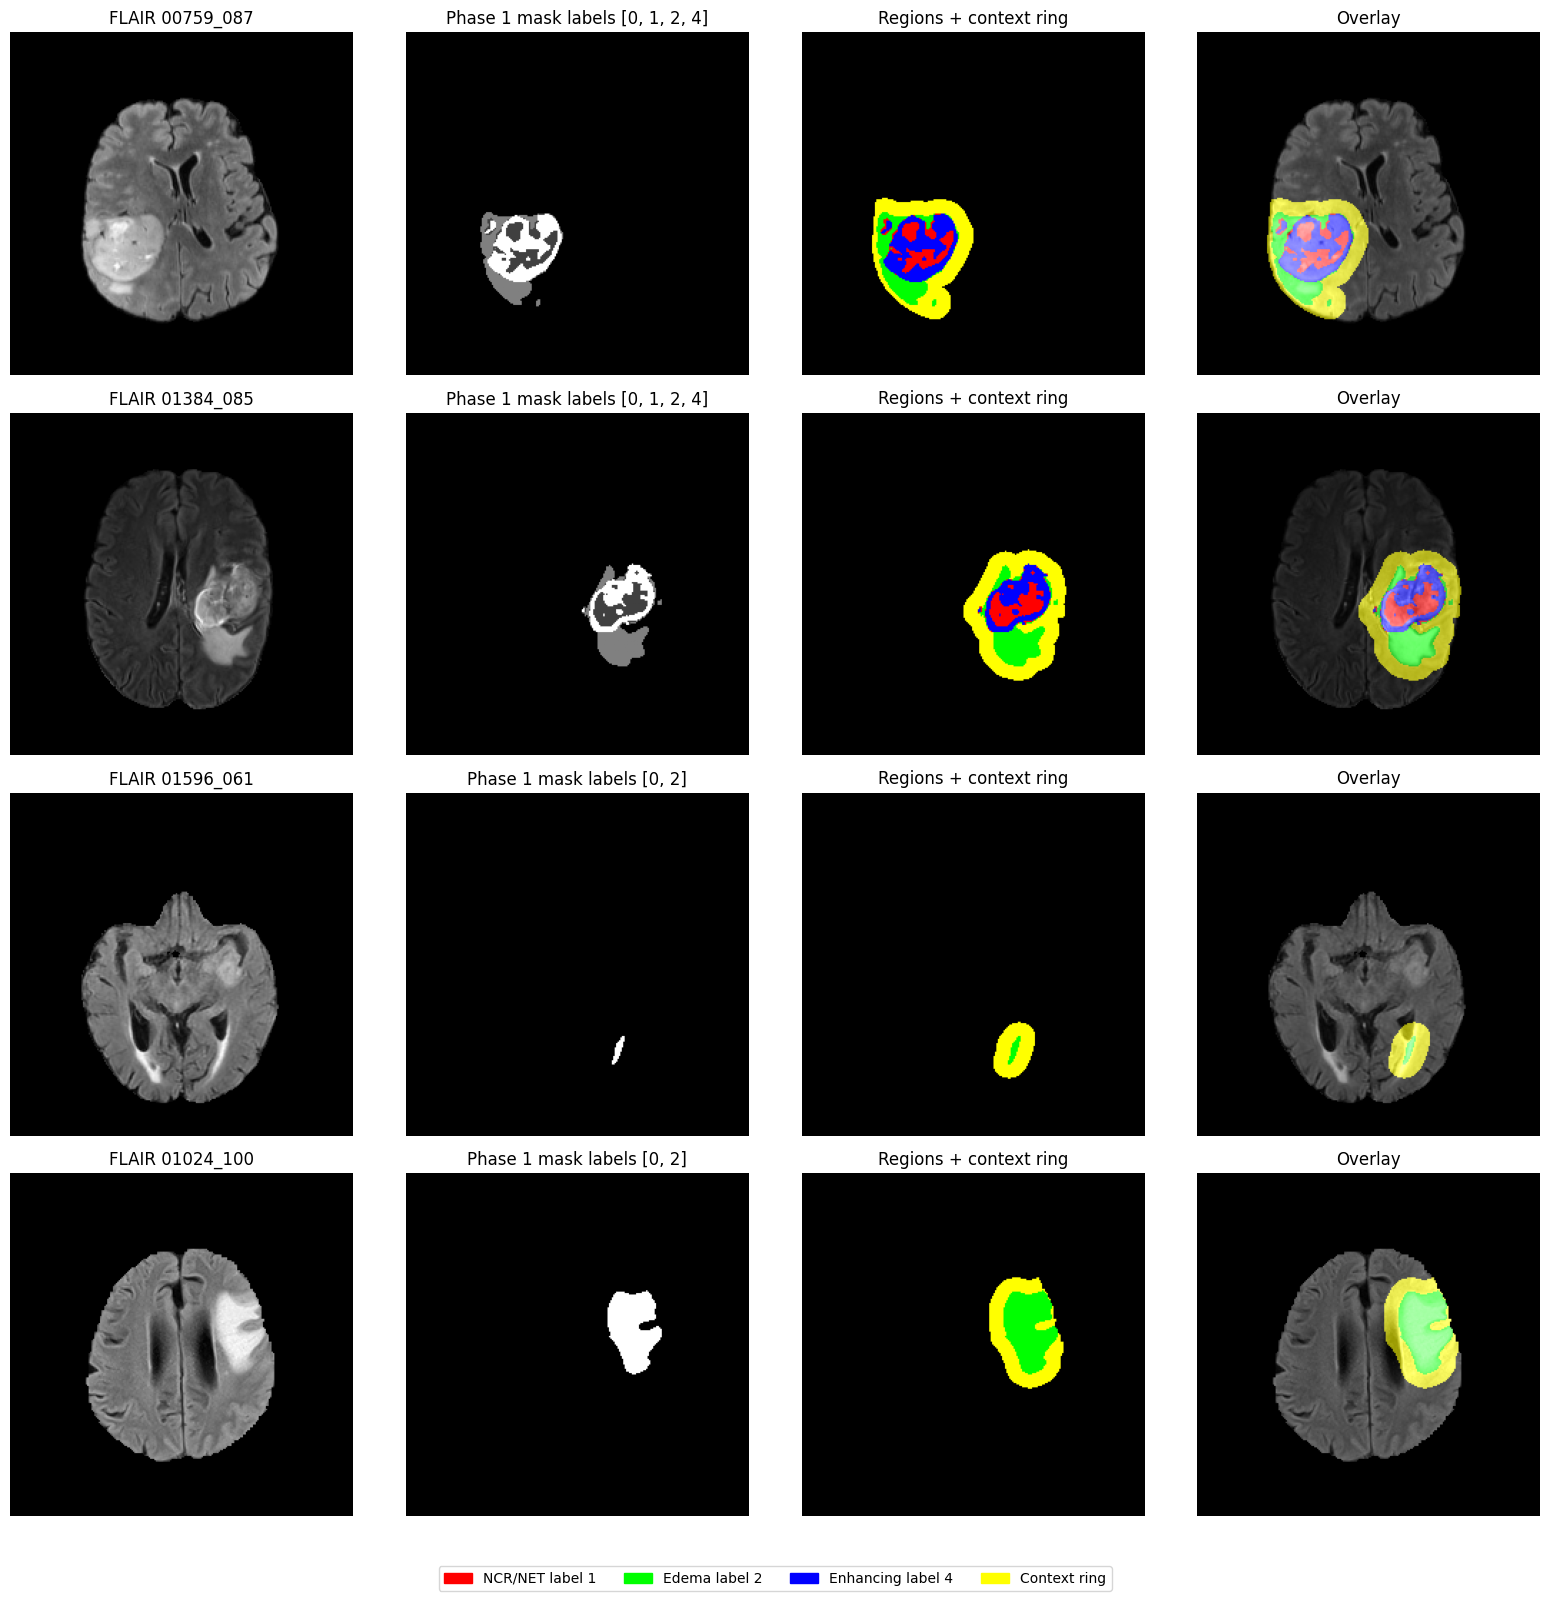

Sample visualization saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/visualizations/sample_region_masks_and_context.png


In [ ]:
def colorize_segmentation_and_context(seg_mask: np.ndarray, context_mask: np.ndarray):
    rgb = np.zeros((seg_mask.shape[0], seg_mask.shape[1], 3), dtype=np.float32)

    # label 1: NCR/NET approximation - red
    rgb[seg_mask == 1] = [1.0, 0.0, 0.0]

    # label 2: edema - green
    rgb[seg_mask == 2] = [0.0, 1.0, 0.0]

    # label 4: enhancing tumor - blue
    rgb[seg_mask == 4] = [0.0, 0.0, 1.0]

    # context ring - yellow
    rgb[context_mask > 0] = [1.0, 1.0, 0.0]

    return rgb


def normalize_for_display(image: np.ndarray):
    image = image.astype(np.float32)
    min_value = image.min()
    max_value = image.max()

    if max_value > min_value:
        return (image - min_value) / (max_value - min_value)

    return np.zeros_like(image, dtype=np.float32)


def visualize_sample_regions(sample_count=4):
    mask_paths = sorted(PHASE1_MASK_SAVE_DIR.glob("*.png"))

    if not mask_paths:
        print("No Phase 1 masks found.")
        return

    sample_count = min(sample_count, len(mask_paths))
    sampled_paths = random.sample(mask_paths, sample_count)

    fig, axes = plt.subplots(sample_count, 4, figsize=(16, 4 * sample_count))

    if sample_count == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, mask_path in enumerate(sampled_paths):
        unique_id = mask_path.stem
        patient_id, slice_id = unique_id.split("_")

        flair_path = image_path_for_modality(DATASET_ROOT, "flair", patient_id, slice_id)
        flair = read_grayscale_png(flair_path, IMAGE_SIZE)

        image_stack, brain_mask, _ = load_4channel_mri_slice(DATASET_ROOT, patient_id, slice_id)
        seg_mask = load_phase1_mask(unique_id)
        region_masks = build_region_masks(seg_mask, brain_mask)

        context_mask = region_masks[TOKEN_NAMES.index("context")]
        colored = colorize_segmentation_and_context(seg_mask, context_mask)

        flair_display = normalize_for_display(flair)
        overlay = np.stack([flair_display] * 3, axis=-1)
        overlay = np.clip(0.70 * overlay + 0.60 * colored, 0, 1)

        axes[row_index, 0].imshow(flair_display, cmap="gray")
        axes[row_index, 0].set_title(f"FLAIR {unique_id}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(seg_mask, cmap="gray")
        axes[row_index, 1].set_title(f"Phase 1 mask labels {np.unique(seg_mask).tolist()}")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].imshow(colored)
        axes[row_index, 2].set_title("Regions + context ring")
        axes[row_index, 2].axis("off")

        axes[row_index, 3].imshow(overlay)
        axes[row_index, 3].set_title("Overlay")
        axes[row_index, 3].axis("off")

    patches = [
        mpatches.Patch(color=[1, 0, 0], label="NCR/NET label 1"),
        mpatches.Patch(color=[0, 1, 0], label="Edema label 2"),
        mpatches.Patch(color=[0, 0, 1], label="Enhancing label 4"),
        mpatches.Patch(color=[1, 1, 0], label="Context ring"),
    ]

    fig.legend(handles=patches, loc="lower center", ncol=4)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    plt.savefig(SAMPLE_VIS_PATH, dpi=150, bbox_inches="tight")
    plt.show()

    print("Sample visualization saved:", SAMPLE_VIS_PATH)


visualize_sample_regions(sample_count=4)


# Final Phase 2A Report

In [ ]:
token_files = sorted(TOKEN_SAVE_DIR.glob("*.pt"))
global_token_manifest_df = rebuild_global_token_manifest()

final_report = {
    "finished_at": now_string(),
    "phase": "Phase 2A - region token generation",
    "status": "complete_or_resume_ready",
    "token_files": len(token_files),
    "manifest_rows": int(len(global_token_manifest_df)) if len(global_token_manifest_df) else 0,
    "token_names": TOKEN_NAMES,
    "token_dim": TOKEN_DIM,
    "token_save_dir": str(TOKEN_SAVE_DIR),
    "global_token_manifest_path": str(GLOBAL_TOKEN_MANIFEST_PATH),
    "validation_summary_path": str(TOKEN_VALIDATION_SUMMARY_PATH),
    "sample_visualization_path": str(SAMPLE_VIS_PATH),
    "encoder_checkpoint_path": str(ENCODER_CHECKPOINT_PATH),
    "context_kernel_size": CONTEXT_KERNEL_SIZE,
    "global_token_uses_brain_foreground": GLOBAL_TOKEN_USES_BRAIN_FOREGROUND,
    "next_step": "Phase 2B - MC Dropout uncertainty map generation",
}

atomic_write_json(PHASE2A_LOG_DIR / "final_phase2a_report.json", final_report)

print("=" * 80)
print("BrainTumorVQA Phase 2A Report")
print("=" * 80)
print("Status: complete or safely resumable")
print("Token files:", len(token_files))
print("Manifest rows:", len(global_token_manifest_df))
print("Token names:", TOKEN_NAMES)
print("Token dimension:", TOKEN_DIM)
print("Token directory:", TOKEN_SAVE_DIR)
print("Global manifest:", GLOBAL_TOKEN_MANIFEST_PATH)
print("Validation summary:", TOKEN_VALIDATION_SUMMARY_PATH)
print("Final report:", PHASE2A_LOG_DIR / "final_phase2a_report.json")
print("=" * 80)

if MAX_PATIENTS_PER_RUN is not None:
    print("\nSmoke test mode was active.")
    print("If outputs look correct, set:")
    print("MAX_PATIENTS_PER_RUN = None")
    print("Then rerun the execution cell.")
else:
    print("\nFull Phase 2A processing attempted.")
    print("If Colab disconnected earlier, rerun from the top. Existing patient token files will be skipped.")


Global token manifest saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/logs/global_token_manifest.csv
Rows: 79864
BrainTumorVQA Phase 2A Report
Status: complete or safely resumable
Token files: 1251
Manifest rows: 79864
Token names: ['edema', 'ncr_net', 'enhancing', 'tumor', 'context', 'global']
Token dimension: 512
Token directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/tokens_by_patient
Global manifest: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/logs/global_token_manifest.csv
Validation summary: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/logs/token_validation_summary.json
Final report: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_br

# ============================================================
# BrainTumorVQA Phase 2B
# MC Dropout Uncertainty Map Generation
#
# Goal:
### Generate pixel-wise uncertainty maps using MC Dropout
### Compute region-level uncertainty scores for UGTM
#
# Input:
### RSNA-BraTS-2021-2D MRI images
### MONAI pretrained BraTS segmentation model
### Phase 1 generated segmentation masks
#
# Output:
###   Per-slice region uncertainty scores:
###       edema, ncr_net, enhancing, tumor, context, global
# ============================================================

In [ ]:
!pip install -q monai nibabel huggingface_hub kaggle opencv-python-headless matplotlib pandas tqdm

import os
import cv2
import csv
import json
import time
import zipfile
import shutil
import random
import warnings
import subprocess
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.amp import autocast

import monai
from monai.networks.nets import SegResNet
from monai.inferers import sliding_window_inference

from huggingface_hub import hf_hub_download

from google.colab import drive, userdata

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries loaded.")
print("PyTorch:", torch.__version__)
print("MONAI:", monai.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Libraries loaded.
PyTorch: 2.10.0+cu128
MONAI: 1.5.2
CUDA available: True
GPU: Tesla T4


# Drive and Phase 1 to Phase 2B Paths and Configuration

In [ ]:
# drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# When use shared google drive in another gmail profile then to validate the path run this else don't run this

In [ ]:
# #drive.mount("/content/drive")

PROJECT_DRIVE_DIR = PROJECT_ROOT

# Phase 1 outputs
PHASE1_DIR = PROJECT_DRIVE_DIR / "phase_1" / "p1a_segmentation_monai_brats"
PHASE1_MASK_SAVE_DIR = PHASE1_DIR / "generated_masks_rsna_2d"
PHASE1_LOG_DIR = PHASE1_DIR / "logs"
PHASE1_GLOBAL_MANIFEST_PATH = PHASE1_LOG_DIR / "global_mask_manifest.csv"

# Phase 2A outputs, useful for alignment but not required for generating uncertainty
PHASE2A_DIR = PROJECT_DRIVE_DIR / "phase_2" / "p2a_region_tokens"
PHASE2A_TOKEN_MANIFEST_PATH = PHASE2A_DIR / "logs" / "global_token_manifest.csv"

# Phase 2B outputs
PHASE2B_DIR = PROJECT_DRIVE_DIR / "phase_2" / "p2b_mc_dropout_uncertainty"
UNCERTAINTY_SAVE_DIR = PHASE2B_DIR / "uncertainty_by_patient"
PHASE2B_LOG_DIR = PHASE2B_DIR / "logs"
PHASE2B_VIS_DIR = PHASE2B_DIR / "visualizations"
PATIENT_UNCERT_DONE_DIR = PHASE2B_LOG_DIR / "patient_done"
PATIENT_UNCERT_MANIFEST_DIR = PHASE2B_LOG_DIR / "patient_manifests"
MODEL_DIR = PHASE1_DIR / "pretrained_models"
TEMP_LOCAL_DIR = TEMP_DIR / "phase2b_temp")

for directory in [
    PHASE2B_DIR,
    UNCERTAINTY_SAVE_DIR,
    PHASE2B_LOG_DIR,
    PHASE2B_VIS_DIR,
    PATIENT_UNCERT_DONE_DIR,
    PATIENT_UNCERT_MANIFEST_DIR,
    MODEL_DIR,
    TEMP_LOCAL_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Dataset
DATASET_ID = "snish9/rsnabrats20212d"
LOCAL_DATASET_DIR = TEMP_DIR / "rsna_brats_2021_2d")

# Keep False to avoid wasting Drive storage on large dataset ZIP.
CACHE_DATASET_ZIP_TO_DRIVE = False
DRIVE_DATASET_ZIP = PHASE2B_DIR / "dataset_cache" / "rsnabrats20212d.zip"

# MONAI pretrained BraTS model
HF_REPO_ID = "MONAI/brats_mri_segmentation"
HF_REVISION = "6ea5b85f04151c71e5599a6f31000e5b042e8d80"
MODEL_PT_PATH = MODEL_DIR / "models" / "model.pt"

# MRI and model settings
IMAGE_SIZE = 240

# MONAI model expects:
# channel 0 = T1ce, channel 1 = T1, channel 2 = T2, channel 3 = FLAIR
MODEL_MODALITY_ORDER = ["t1ce", "t1", "t2", "flair"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
AMP_DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = torch.cuda.is_available()

# ------------------------------------------------------------
# IMPORTANT RUN SETTINGS
# ------------------------------------------------------------
# Smoke test:
#   MC_DROPOUT_PASSES = 5
#   MAX_PATIENTS_PER_RUN = 2
#
# Final research run:
#   MC_DROPOUT_PASSES = 20
#   MAX_PATIENTS_PER_RUN = None
# ------------------------------------------------------------

MC_DROPOUT_PASSES = 20
MAX_PATIENTS_PER_RUN = None

# Optional patient range splitting for multiple Colab sessions.
# Example:
#   session 1: PATIENT_START_INDEX = 0,   PATIENT_END_INDEX = 400
#   session 2: PATIENT_START_INDEX = 400, PATIENT_END_INDEX = 800
#   session 3: PATIENT_START_INDEX = 800, PATIENT_END_INDEX = None
PATIENT_START_INDEX = 0
PATIENT_END_INDEX = None

# Sliding-window inference settings
ROI_DEPTH_CANDIDATES = [160, 128, 96, 64]
SW_BATCH_SIZE = 1
SW_OVERLAP = 0.50

# Resume / overwrite
# Keep False for normal usage.
# Existing patients are skipped only when they were generated with same MC_DROPOUT_PASSES.
OVERWRITE_EXISTING_UNCERTAINTY = False

# Storage settings
# Keep uint8 maps: compact, visualization-friendly, enough for later loading.
# Exact region uncertainty scores are saved as float32 separately.
SAVE_UNCERTAINTY_MAPS_UINT8 = True

# Float16 maps are optional and can use much more Drive space.
# Keep False unless you specifically need continuous maps later.
SAVE_UNCERTAINTY_MAPS_FLOAT16 = False

# Region names must match Phase 2A token order exactly.
TOKEN_REGION_NAMES = [
    "edema",
    "ncr_net",
    "enhancing",
    "tumor",
    "context",
    "global",
]

# Context ring must match Phase 2A setting.
CONTEXT_KERNEL_SIZE = 21
GLOBAL_REGION_USES_BRAIN_FOREGROUND = True

RUN_CONFIG_PATH = PHASE2B_LOG_DIR / "phase2b_uncertainty_config.json"
GLOBAL_UNCERTAINTY_MANIFEST_PATH = PHASE2B_LOG_DIR / "global_uncertainty_manifest.csv"
UNCERTAINTY_VALIDATION_SUMMARY_PATH = PHASE2B_LOG_DIR / "uncertainty_validation_summary.json"
SAMPLE_UNCERTAINTY_VIS_PATH = PHASE2B_VIS_DIR / "sample_uncertainty_overlay.png"

assert PHASE1_MASK_SAVE_DIR.exists(), f"Phase 1 mask directory not found: {PHASE1_MASK_SAVE_DIR}"

print("Project dir:", PROJECT_DRIVE_DIR)
print("Phase 1 mask dir:", PHASE1_MASK_SAVE_DIR)
print("Phase 2B uncertainty dir:", UNCERTAINTY_SAVE_DIR)
print("Device:", DEVICE)
print("MC_DROPOUT_PASSES:", MC_DROPOUT_PASSES)
print("MAX_PATIENTS_PER_RUN:", MAX_PATIENTS_PER_RUN)


Project dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
Phase 1 mask dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/generated_masks_rsna_2d
Phase 2B uncertainty dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/uncertainty_by_patient
Device: cuda
MC_DROPOUT_PASSES: 20
MAX_PATIENTS_PER_RUN: None


# Ensure that Phase 1 and Phase 2 results present or not
# This is needed because we are using shared google drive from parent account

In [ ]:
print("Phase 1 masks:", len(list(PHASE1_MASK_SAVE_DIR.glob("*.png"))))
print("Phase 2A token files:", len(list((PHASE2A_DIR / "tokens_by_patient").glob("*.pt"))))

Phase 1 masks: 79864
Phase 2A token files: 1251


# Persistence Helpers

In [ ]:
def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def atomic_write_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)
    os.replace(temp_path, path)


def read_json(path: Path, default):
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def atomic_torch_save(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, temp_path)
    os.replace(temp_path, path)


def atomic_write_csv(path: Path, rows: list, fieldnames: list):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    os.replace(temp_path, path)


def safe_copy_to_drive(local_path: Path, final_drive_path: Path):
    final_drive_path.parent.mkdir(parents=True, exist_ok=True)
    temp_drive_path = final_drive_path.with_suffix(final_drive_path.suffix + ".tmp")
    shutil.copy2(local_path, temp_drive_path)
    os.replace(temp_drive_path, final_drive_path)


phase2b_config = {
    "created_at": now_string(),
    "phase": "Phase 2B - MC Dropout uncertainty map generation",
    "dataset_id": DATASET_ID,
    "model": HF_REPO_ID,
    "model_revision": HF_REVISION,
    "phase1_mask_dir": str(PHASE1_MASK_SAVE_DIR),
    "uncertainty_save_dir": str(UNCERTAINTY_SAVE_DIR),
    "mc_dropout_passes": MC_DROPOUT_PASSES,
    "uncertainty_method": (
        "MC Dropout predictive probability variance over MONAI TC/WT/ET output channels; "
        "mean channel variance normalized by Bernoulli max variance 0.25."
    ),
    "model_output_channels": {
        "0": "TC - tumor core",
        "1": "WT - whole tumor",
        "2": "ET - enhancing tumor",
    },
    "region_uncertainty_names": TOKEN_REGION_NAMES,
    "context_kernel_size": CONTEXT_KERNEL_SIZE,
    "global_region_uses_brain_foreground": GLOBAL_REGION_USES_BRAIN_FOREGROUND,
    "save_uncertainty_maps_uint8": SAVE_UNCERTAINTY_MAPS_UINT8,
    "save_uncertainty_maps_float16": SAVE_UNCERTAINTY_MAPS_FLOAT16,
    "resume_policy": (
        "Patient is skipped only if uncertainty file, done marker, and manifest exist "
        "and were generated with the same MC_DROPOUT_PASSES."
    ),
}

atomic_write_json(RUN_CONFIG_PATH, phase2b_config)
print("Phase 2B config saved:", RUN_CONFIG_PATH)


Phase 2B config saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/logs/phase2b_uncertainty_config.json


# Download or Restore RSNA-BraTS 2D Dataset

In [ ]:
def has_valid_dataset_root(path: Path):
    return (
        path.exists()
        and (path / "target.csv").exists()
        and (path / "flair").exists()
        and (path / "t1").exists()
        and (path / "t1ce").exists()
        and (path / "t2").exists()
    )


def find_dataset_root(search_root: Path):
    if has_valid_dataset_root(search_root):
        return search_root

    candidates = []
    for csv_path in search_root.rglob("target.csv"):
        parent = csv_path.parent
        if has_valid_dataset_root(parent):
            candidates.append(parent)

    if not candidates:
        raise FileNotFoundError(
            f"Could not find dataset root under {search_root}. "
            "Expected target.csv plus flair/t1/t1ce/t2 folders."
        )

    return candidates[0]


def download_or_restore_dataset():
    if has_valid_dataset_root(LOCAL_DATASET_DIR):
        print("Dataset already exists locally:", LOCAL_DATASET_DIR)
        return find_dataset_root(LOCAL_DATASET_DIR)

    LOCAL_DATASET_DIR.mkdir(parents=True, exist_ok=True)
    local_zip_path = LOCAL_DATASET_DIR / "rsnabrats20212d.zip"

    if CACHE_DATASET_ZIP_TO_DRIVE and DRIVE_DATASET_ZIP.exists():
        print("Restoring dataset zip from Drive cache...")
        shutil.copy2(DRIVE_DATASET_ZIP, local_zip_path)
    else:
        print("Downloading dataset from Kaggle...")

        kaggle_username = userdata.get("KAGGLE_USERNAME")
        kaggle_key = userdata.get("KAGGLE_KEY")

        if not kaggle_username or not kaggle_key:
            raise RuntimeError(
                "Kaggle credentials missing. Add KAGGLE_USERNAME and KAGGLE_KEY "
                "to Colab Secrets and enable notebook access."
            )

        os.environ["KAGGLE_USERNAME"] = kaggle_username
        os.environ["KAGGLE_KEY"] = kaggle_key

        subprocess.run(
            ["kaggle", "datasets", "download", "-d", DATASET_ID, "-p", str(LOCAL_DATASET_DIR)],
            check=True,
        )

        zip_files = sorted(
            LOCAL_DATASET_DIR.glob("*.zip"),
            key=lambda path: path.stat().st_size,
            reverse=True,
        )

        if not zip_files:
            raise FileNotFoundError("Kaggle download completed, but no ZIP file was found.")

        downloaded_zip = zip_files[0]
        downloaded_zip.rename(local_zip_path)

        if CACHE_DATASET_ZIP_TO_DRIVE:
            print("Caching dataset ZIP to Drive...")
            safe_copy_to_drive(local_zip_path, DRIVE_DATASET_ZIP)

    print("Unzipping dataset locally...")
    with zipfile.ZipFile(local_zip_path, "r") as zip_ref:
        zip_ref.extractall(LOCAL_DATASET_DIR)

    dataset_root = find_dataset_root(LOCAL_DATASET_DIR)
    print("Dataset root:", dataset_root)
    return dataset_root


DATASET_ROOT = download_or_restore_dataset()
CSV_PATH = DATASET_ROOT / "target.csv"

print("CSV path:", CSV_PATH)
for modality in ["flair", "t1", "t1ce", "t2"]:
    print(modality, "files:", len(list((DATASET_ROOT / modality).glob("*.png"))))


Unzipping dataset locally...
Dataset root: /content/rsna_brats_2021_2d
CSV path: /content/rsna_brats_2021_2d/target.csv
flair files: 79864
t1 files: 79864
t1ce files: 79864
t2 files: 79864


# Load CSV and Validate Phase 1 Mask Completion

In [ ]:
def load_target_dataframe(csv_path: Path):
    df = pd.read_csv(
        csv_path,
        dtype={
            "BraTS21ID": str,
            "image_id": str,
            "tumor_slice": int,
        },
    )

    df["BraTS21ID"] = df["BraTS21ID"].astype(str).str.zfill(5)
    df["image_id"] = df["image_id"].astype(str).str.zfill(3)
    df["slice_int"] = df["image_id"].astype(int)
    df["unique_id"] = df["BraTS21ID"] + "_" + df["image_id"]

    df = df.sort_values(["BraTS21ID", "slice_int"]).reset_index(drop=True)
    return df


def image_path_for_modality(dataset_root: Path, modality: str, patient_id: str, slice_id: str):
    return dataset_root / modality / f"{modality}_BraTS2021_{patient_id}_{slice_id}.png"


def phase1_mask_path_for_unique_id(unique_id: str):
    return PHASE1_MASK_SAVE_DIR / f"{unique_id}.png"


df_all = load_target_dataframe(CSV_PATH)

phase1_mask_count = len(list(PHASE1_MASK_SAVE_DIR.glob("*.png")))

missing_phase1_masks = 0
for unique_id in df_all["unique_id"].tolist():
    if not phase1_mask_path_for_unique_id(unique_id).exists():
        missing_phase1_masks += 1

print("CSV rows:", len(df_all))
print("Unique patients:", df_all["BraTS21ID"].nunique())
print("Phase 1 masks:", phase1_mask_count)
print("Rows without Phase 1 mask:", missing_phase1_masks)
display(df_all.head())

if phase1_mask_count < 79000:
    raise RuntimeError(
        "Phase 1 appears incomplete. Please complete Phase 1 before full Phase 2B."
    )

if missing_phase1_masks > 100:
    raise RuntimeError(
        "Too many Phase 1 masks are missing. Expected around 57 missing rows only."
    )

print("Phase 1 mask availability looks healthy.")


CSV rows: 79921
Unique patients: 1251
Phase 1 masks: 79864
Rows without Phase 1 mask: 57


,BraTS21ID,image_id,tumor_slice,slice_int,unique_id
0,00000,049,0,49,00000_049
1,00000,050,0,50,00000_050
2,00000,051,0,51,00000_051
3,00000,052,1,52,00000_052
4,00000,053,1,53,00000_053


Phase 1 mask availability looks healthy.


# Build or Load MONAI Pretrained Segmentation Model

In [ ]:
def download_monai_model_if_needed():
    if MODEL_PT_PATH.exists():
        print("MONAI model already exists in Drive:", MODEL_PT_PATH)
        return MODEL_PT_PATH

    print("Downloading MONAI BraTS pretrained model from Hugging Face...")

    model_path = hf_hub_download(
        repo_id=HF_REPO_ID,
        filename="models/model.pt",
        revision=HF_REVISION,
        local_dir=str(MODEL_DIR),
    )

    for filename in [
        "configs/inference.json",
        "configs/metadata.json",
        "docs/README.md",
        "LICENSE",
    ]:
        try:
            hf_hub_download(
                repo_id=HF_REPO_ID,
                filename=filename,
                revision=HF_REVISION,
                local_dir=str(MODEL_DIR),
            )
        except Exception as error:
            print(f"Warning: could not download {filename}: {error}")

    print("Model downloaded:", model_path)
    return Path(model_path)


def clean_state_dict_keys(state_dict):
    cleaned = {}
    prefixes = ["module.", "network.", "model."]

    for key, value in state_dict.items():
        new_key = key
        changed = True

        while changed:
            changed = False
            for prefix in prefixes:
                if new_key.startswith(prefix):
                    new_key = new_key[len(prefix):]
                    changed = True

        cleaned[new_key] = value

    return cleaned


def extract_model_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for candidate_key in ["model", "model_state_dict", "state_dict", "network"]:
            if candidate_key in checkpoint and isinstance(checkpoint[candidate_key], dict):
                print(f"Using checkpoint key: {candidate_key}")
                return checkpoint[candidate_key]

        if all(isinstance(key, str) for key in checkpoint.keys()):
            print("Using checkpoint as raw state_dict.")
            return checkpoint

    raise ValueError("Could not extract model state_dict from checkpoint.")


def build_monai_brats_model(device):
    model = SegResNet(
        blocks_down=[1, 2, 2, 4],
        blocks_up=[1, 1, 1],
        init_filters=16,
        in_channels=4,
        out_channels=3,
        dropout_prob=0.2,
    )
    return model.to(device)


model_path = download_monai_model_if_needed()

seg_model = build_monai_brats_model(DEVICE)

try:
    checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(model_path, map_location=DEVICE)

state_dict = extract_model_state_dict(checkpoint)
state_dict = clean_state_dict_keys(state_dict)

missing_keys, unexpected_keys = seg_model.load_state_dict(state_dict, strict=False)

if missing_keys:
    print("Missing keys:", missing_keys[:10], "..." if len(missing_keys) > 10 else "")
if unexpected_keys:
    print("Unexpected keys:", unexpected_keys[:10], "..." if len(unexpected_keys) > 10 else "")

if missing_keys or unexpected_keys:
    print("Warning: non-strict checkpoint loading happened. Validate outputs carefully.")
else:
    print("Segmentation model loaded cleanly.")

seg_model.eval()
torch.backends.cudnn.benchmark = True

total_params = sum(param.numel() for param in seg_model.parameters())
print("Segmentation model parameters:", f"{total_params:,}")
print("Segmentation model ready on:", DEVICE)


MONAI model already exists in Drive: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_1_segmentation_monai_brats/pretrained_models/models/model.pt
Using checkpoint as raw state_dict.
Segmentation model loaded cleanly.
Segmentation model parameters: 4,702,227
Segmentation model ready on: cuda


# Enable MC Dropout Safely

In [ ]:
DROPOUT_TYPES = (
    nn.Dropout,
    nn.Dropout2d,
    nn.Dropout3d,
    nn.AlphaDropout,
)

def enable_mc_dropout_only(model: nn.Module):
    """
    Keep model in eval mode, but activate dropout layers only.
    This avoids changing normalization behavior while enabling stochastic dropout.
    """
    model.eval()

    dropout_count = 0

    for module in model.modules():
        if isinstance(module, DROPOUT_TYPES):
            module.train()
            dropout_count += 1

    return dropout_count


dropout_count = enable_mc_dropout_only(seg_model)

print("Dropout layers activated:", dropout_count)

if dropout_count == 0:
    print("Warning: No dropout layers found. MC uncertainty may become deterministic.")
else:
    print("MC Dropout mode ready: model.eval() + dropout layers train().")


Dropout layers activated: 1
MC Dropout mode ready: model.eval() + dropout layers train().


# Image Volume, Phase 1 Mask, and Region Mask Helpers

In [ ]:
def read_grayscale_png(path: Path, image_size: int = 240):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    if image.shape != (image_size, image_size):
        image = cv2.resize(image, (image_size, image_size), interpolation=cv2.INTER_LINEAR)

    return image.astype(np.float32)


def normalize_nonzero_channel(volume_3d: np.ndarray):
    """
    Same normalization style as Phase 1:
    per-channel non-zero z-score normalization.
    volume_3d shape: [H, W, D]
    """
    volume_3d = volume_3d.astype(np.float32)
    output = np.zeros_like(volume_3d, dtype=np.float32)

    nonzero_mask = volume_3d != 0
    if not np.any(nonzero_mask):
        return output

    values = volume_3d[nonzero_mask]
    mean = values.mean()
    std = values.std()

    if std < 1e-8:
        std = 1.0

    output[nonzero_mask] = (volume_3d[nonzero_mask] - mean) / std
    return output


def build_patient_volume(df_patient: pd.DataFrame, dataset_root: Path):
    """
    Returns:
        volume_tensor: [1, 4, H, W, D]
        slice_info: list of dicts
        brain_masks: [H, W, D]
    """
    df_patient = df_patient.sort_values("slice_int").reset_index(drop=True)

    channel_volumes = []
    raw_channel_volumes = []
    slice_info = []

    for modality in MODEL_MODALITY_ORDER:
        modality_slices = []
        raw_modality_slices = []

        for row in df_patient.itertuples(index=False):
            path = image_path_for_modality(dataset_root, modality, row.BraTS21ID, row.image_id)
            image = read_grayscale_png(path, IMAGE_SIZE)

            if image is None:
                image = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)

            raw_modality_slices.append(image)
            modality_slices.append(image)

        raw_volume = np.stack(raw_modality_slices, axis=-1)
        norm_volume = normalize_nonzero_channel(np.stack(modality_slices, axis=-1))

        raw_channel_volumes.append(raw_volume)
        channel_volumes.append(norm_volume)

    raw_stack = np.stack(raw_channel_volumes, axis=0)
    brain_masks = np.any(raw_stack > 0, axis=0).astype(np.uint8)

    for row in df_patient.itertuples(index=False):
        missing_modalities = []
        for modality in ["flair", "t1", "t1ce", "t2"]:
            path = image_path_for_modality(dataset_root, modality, row.BraTS21ID, row.image_id)
            if not path.exists():
                missing_modalities.append(modality)

        slice_info.append(
            {
                "patient_id": row.BraTS21ID,
                "slice_id": row.image_id,
                "slice_int": int(row.slice_int),
                "unique_id": row.unique_id,
                "tumor_slice": int(row.tumor_slice),
                "missing_modalities": missing_modalities,
            }
        )

    volume_np = np.stack(channel_volumes, axis=0)
    volume_tensor = torch.from_numpy(volume_np).unsqueeze(0).float()

    return volume_tensor, slice_info, brain_masks


def load_phase1_mask(unique_id: str):
    path = phase1_mask_path_for_unique_id(unique_id)
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return None

    if mask.shape != (IMAGE_SIZE, IMAGE_SIZE):
        mask = cv2.resize(mask, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_NEAREST)

    return mask.astype(np.uint8)


def build_region_masks(seg_mask: np.ndarray, brain_mask: np.ndarray):
    """
    Region order must match Phase 2A:
        edema, ncr_net, enhancing, tumor, context, global
    """
    edema = (seg_mask == 2).astype(np.uint8)
    ncr_net = (seg_mask == 1).astype(np.uint8)
    enhancing = (seg_mask == 4).astype(np.uint8)
    tumor = (seg_mask > 0).astype(np.uint8)

    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (CONTEXT_KERNEL_SIZE, CONTEXT_KERNEL_SIZE),
    )

    dilated_tumor = cv2.dilate(tumor, kernel, iterations=1)
    context = ((dilated_tumor > 0) & (tumor == 0)).astype(np.uint8)
    context = (context & (brain_mask > 0)).astype(np.uint8)

    if GLOBAL_REGION_USES_BRAIN_FOREGROUND:
        global_region = (brain_mask > 0).astype(np.uint8)

        if global_region.sum() == 0:
            global_region = np.ones_like(seg_mask, dtype=np.uint8)
    else:
        global_region = np.ones_like(seg_mask, dtype=np.uint8)

    region_masks = np.stack(
        [
            edema,
            ncr_net,
            enhancing,
            tumor,
            context,
            global_region,
        ],
        axis=0,
    ).astype(np.uint8)

    return region_masks


print("Volume and region helper functions ready.")


Volume and region helper functions ready.


# MC Dropout Inference and Uncertainty Computation

In [ ]:
def sliding_window_predict_once(volume_tensor: torch.Tensor, roi_depth: int):
    """
    Returns sigmoid probabilities:
        [3, H, W, D] on CPU float32

    Model outputs:
        channel 0 = TC
        channel 1 = WT
        channel 2 = ET
    """
    roi_size = (IMAGE_SIZE, IMAGE_SIZE, roi_depth)

    volume_tensor = volume_tensor.to(DEVICE, non_blocking=True)

    with torch.no_grad():
        with autocast(device_type=AMP_DEVICE_TYPE, enabled=USE_AMP):
            logits = sliding_window_inference(
                inputs=volume_tensor,
                roi_size=roi_size,
                sw_batch_size=SW_BATCH_SIZE,
                predictor=seg_model,
                overlap=SW_OVERLAP,
                mode="gaussian",
            )

            probs = torch.sigmoid(logits)

    probs_cpu = probs.squeeze(0).detach().float().cpu()

    del logits, probs

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return probs_cpu


def mc_dropout_uncertainty_for_patient(volume_tensor: torch.Tensor):
    """
    Computes MC variance uncertainty using Welford online update.

    Why online update?
    It avoids storing all T predictions in memory.

    Returns:
        uncertainty_map: [H, W, D], float32 in [0, 1]
        roi_depth_used: int
    """
    if MC_DROPOUT_PASSES < 2:
        print("Warning: MC_DROPOUT_PASSES < 2 gives zero variance uncertainty.")

    last_error = None

    for roi_depth in ROI_DEPTH_CANDIDATES:
        try:
            mean_probs = None
            m2_probs = None

            for sample_index in range(MC_DROPOUT_PASSES):
                enable_mc_dropout_only(seg_model)

                probs = sliding_window_predict_once(volume_tensor, roi_depth)

                if mean_probs is None:
                    mean_probs = torch.zeros_like(probs, dtype=torch.float32)
                    m2_probs = torch.zeros_like(probs, dtype=torch.float32)

                delta = probs - mean_probs
                mean_probs += delta / float(sample_index + 1)
                delta2 = probs - mean_probs
                m2_probs += delta * delta2

                del probs

                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()

            if MC_DROPOUT_PASSES > 1:
                variance = m2_probs / float(MC_DROPOUT_PASSES - 1)
            else:
                variance = torch.zeros_like(mean_probs)

            # Bernoulli probability variance max is 0.25.
            # Normalize to [0, 1].
            uncertainty = variance.mean(dim=0) / 0.25
            uncertainty = torch.clamp(uncertainty, 0.0, 1.0)

            uncertainty_np = uncertainty.numpy().astype(np.float32)

            del mean_probs, m2_probs, variance, uncertainty

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

            return uncertainty_np, roi_depth

        except RuntimeError as error:
            last_error = error
            error_text = str(error).lower()

            if "out of memory" in error_text or "cuda" in error_text:
                print(f"CUDA issue with ROI depth {roi_depth}. Retrying smaller ROI...")
                if DEVICE.type == "cuda":
                    torch.cuda.empty_cache()
                time.sleep(2)
                continue

            raise error

    raise RuntimeError(f"All ROI depths failed. Last error: {last_error}")


def uncertainty_float_to_uint8(uncertainty_map: np.ndarray):
    uncertainty_map = np.nan_to_num(uncertainty_map, nan=0.0, posinf=1.0, neginf=0.0)
    uncertainty_map = np.clip(uncertainty_map, 0.0, 1.0)
    return np.round(uncertainty_map * 255.0).astype(np.uint8)


def compute_region_uncertainties_for_slice(uncertainty_2d: np.ndarray, region_masks: np.ndarray):
    """
    uncertainty_2d: [H, W], float in [0, 1]
    region_masks: [6, H, W], uint8

    Returns:
        region_scores: 6 floats in [0, 1]
        region_present: 6 bools
        region_areas: 6 ints
    """
    region_scores = []
    region_present = []
    region_areas = []

    for region_index in range(region_masks.shape[0]):
        mask = region_masks[region_index] > 0
        area = int(mask.sum())

        region_areas.append(area)
        region_present.append(area > 0)

        if area > 0:
            score = float(uncertainty_2d[mask].mean())
        else:
            score = 0.0

        region_scores.append(score)

    return region_scores, region_present, region_areas


print("MC Dropout uncertainty functions ready.")


MC Dropout uncertainty functions ready.


# Patient-Level Resume-Safe Uncertainty Generation

In [ ]:
MANIFEST_FIELDS = [
    "patient_id",
    "slice_id",
    "unique_id",
    "tumor_slice_csv",
    "uncertainty_file",
    "slice_index_in_uncertainty_file",
    "uncertainty_map_shape",
    "mc_dropout_passes",
    "roi_depth_used",
    "edema_uncertainty",
    "ncr_net_uncertainty",
    "enhancing_uncertainty",
    "tumor_uncertainty",
    "context_uncertainty",
    "global_uncertainty",
    "edema_present",
    "ncr_net_present",
    "enhancing_present",
    "tumor_present",
    "context_present",
    "global_present",
    "edema_area_pixels",
    "ncr_net_area_pixels",
    "enhancing_area_pixels",
    "tumor_area_pixels",
    "context_area_pixels",
    "global_area_pixels",
    "missing_modalities",
    "mask_missing",
    "saved_at",
]


def patient_uncertainty_file_path(patient_id: str):
    return UNCERTAINTY_SAVE_DIR / f"{patient_id}.pt"


def patient_done_path(patient_id: str):
    return PATIENT_UNCERT_DONE_DIR / f"{patient_id}.json"


def patient_manifest_path(patient_id: str):
    return PATIENT_UNCERT_MANIFEST_DIR / f"{patient_id}.csv"


def patient_already_done(patient_id: str):
    """
    Safer resume check:
    skip only if the patient was completed with the same MC_DROPOUT_PASSES.
    This prevents mixing T=5 smoke-test files with T=20 final files.
    """
    if OVERWRITE_EXISTING_UNCERTAINTY:
        return False

    uncertainty_file = patient_uncertainty_file_path(patient_id)
    done_file = patient_done_path(patient_id)
    manifest_file = patient_manifest_path(patient_id)

    if not (uncertainty_file.exists() and done_file.exists() and manifest_file.exists()):
        return False

    try:
        done_data = read_json(done_file, {})
        done_passes = int(done_data.get("mc_dropout_passes", -1))

        if done_passes != int(MC_DROPOUT_PASSES):
            return False

        payload = torch.load(uncertainty_file, map_location="cpu")
        payload_passes = int(payload.get("mc_dropout_passes", -1))

        if payload_passes != int(MC_DROPOUT_PASSES):
            return False

        return True

    except Exception:
        return False


def process_one_patient_for_uncertainty(patient_id: str, df_patient: pd.DataFrame):
    started_at = time.time()

    if patient_already_done(patient_id):
        done_data = read_json(patient_done_path(patient_id), {})
        return {
            "patient_id": patient_id,
            "status": "skipped_already_done",
            "saved_slices": 0,
            "existing_slices": int(done_data.get("saved_slices", 0)),
            "skipped_slices": int(done_data.get("skipped_slices", 0)),
            "mc_dropout_passes": int(done_data.get("mc_dropout_passes", MC_DROPOUT_PASSES)),
            "elapsed_sec": round(time.time() - started_at, 2),
        }

    df_patient = df_patient.sort_values("slice_int").reset_index(drop=True)

    volume_tensor, slice_info, brain_masks = build_patient_volume(df_patient, DATASET_ROOT)

    uncertainty_map_3d, roi_depth_used = mc_dropout_uncertainty_for_patient(volume_tensor)
    uncertainty_uint8_3d = uncertainty_float_to_uint8(uncertainty_map_3d)

    valid_unique_ids = []
    valid_slice_ids = []
    tumor_slice_csv = []
    valid_depth_indices = []

    region_uncertainty_rows = []
    region_present_rows = []
    region_area_rows = []
    manifest_rows = []
    skipped_rows = []

    for depth_index, info in enumerate(slice_info):
        unique_id = info["unique_id"]

        seg_mask = load_phase1_mask(unique_id)

        if seg_mask is None:
            skipped_rows.append(
                {
                    "unique_id": unique_id,
                    "reason": "missing_phase1_mask",
                    "missing_modalities": info["missing_modalities"],
                }
            )
            continue

        if info["missing_modalities"]:
            skipped_rows.append(
                {
                    "unique_id": unique_id,
                    "reason": "missing_mri_modality",
                    "missing_modalities": info["missing_modalities"],
                }
            )
            continue

        brain_mask_2d = brain_masks[:, :, depth_index]
        region_masks = build_region_masks(seg_mask, brain_mask_2d)

        uncertainty_2d = uncertainty_map_3d[:, :, depth_index]

        region_scores, region_present, region_areas = compute_region_uncertainties_for_slice(
            uncertainty_2d,
            region_masks,
        )

        valid_unique_ids.append(unique_id)
        valid_slice_ids.append(info["slice_id"])
        tumor_slice_csv.append(info["tumor_slice"])
        valid_depth_indices.append(depth_index)

        region_uncertainty_rows.append(region_scores)
        region_present_rows.append(region_present)
        region_area_rows.append(region_areas)

    if len(valid_depth_indices) == 0:
        done_payload = {
            "patient_id": patient_id,
            "status": "no_valid_slices",
            "saved_slices": 0,
            "skipped_slices": len(skipped_rows),
            "mc_dropout_passes": MC_DROPOUT_PASSES,
            "skipped_rows": skipped_rows,
            "finished_at": now_string(),
            "elapsed_sec": round(time.time() - started_at, 2),
        }
        atomic_write_json(patient_done_path(patient_id), done_payload)
        return done_payload

    selected_uncertainty_uint8 = uncertainty_uint8_3d[:, :, valid_depth_indices]

    if SAVE_UNCERTAINTY_MAPS_FLOAT16:
        selected_uncertainty_float16 = uncertainty_map_3d[:, :, valid_depth_indices].astype(np.float16)
    else:
        selected_uncertainty_float16 = None

    uncertainty_payload = {
        "patient_id": patient_id,
        "created_at": now_string(),
        "unique_ids": valid_unique_ids,
        "slice_ids": valid_slice_ids,
        "tumor_slice_csv": tumor_slice_csv,
        "mc_dropout_passes": MC_DROPOUT_PASSES,
        "roi_depth_used": roi_depth_used,
        "uncertainty_method": "MC variance mean across TC, WT, ET channels normalized by 0.25",
        "uncertainty_range": "[0, 1]",
        "uncertainty_uint8_scale": "uint8_value / 255.0",
        "region_names": TOKEN_REGION_NAMES,
        "region_uncertainty": torch.tensor(region_uncertainty_rows, dtype=torch.float32),
        "region_present": torch.tensor(region_present_rows, dtype=torch.bool),
        "region_area_pixels": torch.tensor(region_area_rows, dtype=torch.long),
        "context_kernel_size": CONTEXT_KERNEL_SIZE,
        "global_region_uses_brain_foreground": GLOBAL_REGION_USES_BRAIN_FOREGROUND,
        "skipped_rows": skipped_rows,
    }

    if SAVE_UNCERTAINTY_MAPS_UINT8:
        # Save as [N, H, W] for simple later indexing.
        uncertainty_payload["uncertainty_maps_uint8"] = torch.from_numpy(
            np.moveaxis(selected_uncertainty_uint8, -1, 0)
        ).to(torch.uint8)

    if SAVE_UNCERTAINTY_MAPS_FLOAT16 and selected_uncertainty_float16 is not None:
        uncertainty_payload["uncertainty_maps_float16"] = torch.from_numpy(
            np.moveaxis(selected_uncertainty_float16, -1, 0)
        ).to(torch.float16)

    uncertainty_file = patient_uncertainty_file_path(patient_id)
    atomic_torch_save(uncertainty_payload, uncertainty_file)

    for slice_index, unique_id in enumerate(valid_unique_ids):
        scores = region_uncertainty_rows[slice_index]
        present = region_present_rows[slice_index]
        areas = region_area_rows[slice_index]

        manifest_rows.append(
            {
                "patient_id": patient_id,
                "slice_id": valid_slice_ids[slice_index],
                "unique_id": unique_id,
                "tumor_slice_csv": tumor_slice_csv[slice_index],
                "uncertainty_file": str(uncertainty_file),
                "slice_index_in_uncertainty_file": slice_index,
                "uncertainty_map_shape": json.dumps([IMAGE_SIZE, IMAGE_SIZE]),
                "mc_dropout_passes": MC_DROPOUT_PASSES,
                "roi_depth_used": roi_depth_used,
                "edema_uncertainty": scores[0],
                "ncr_net_uncertainty": scores[1],
                "enhancing_uncertainty": scores[2],
                "tumor_uncertainty": scores[3],
                "context_uncertainty": scores[4],
                "global_uncertainty": scores[5],
                "edema_present": present[0],
                "ncr_net_present": present[1],
                "enhancing_present": present[2],
                "tumor_present": present[3],
                "context_present": present[4],
                "global_present": present[5],
                "edema_area_pixels": areas[0],
                "ncr_net_area_pixels": areas[1],
                "enhancing_area_pixels": areas[2],
                "tumor_area_pixels": areas[3],
                "context_area_pixels": areas[4],
                "global_area_pixels": areas[5],
                "missing_modalities": json.dumps([]),
                "mask_missing": False,
                "saved_at": now_string(),
            }
        )

    atomic_write_csv(patient_manifest_path(patient_id), manifest_rows, MANIFEST_FIELDS)

    done_payload = {
        "patient_id": patient_id,
        "status": "complete",
        "saved_slices": len(valid_unique_ids),
        "skipped_slices": len(skipped_rows),
        "uncertainty_file": str(uncertainty_file),
        "manifest_file": str(patient_manifest_path(patient_id)),
        "mc_dropout_passes": MC_DROPOUT_PASSES,
        "roi_depth_used": roi_depth_used,
        "saved_uint8_maps": SAVE_UNCERTAINTY_MAPS_UINT8,
        "saved_float16_maps": SAVE_UNCERTAINTY_MAPS_FLOAT16,
        "skipped_rows": skipped_rows,
        "finished_at": now_string(),
        "elapsed_sec": round(time.time() - started_at, 2),
    }

    atomic_write_json(patient_done_path(patient_id), done_payload)

    del uncertainty_map_3d, uncertainty_uint8_3d

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

    return done_payload


print("Patient uncertainty generation function ready.")


Patient uncertainty generation function ready.


# Execute Phase 2B MC Dropout Uncertainty Generation
# Clean Resume-Safe Version

In [ ]:
all_patient_ids = sorted(df_all["BraTS21ID"].unique().tolist())

# Optional range split for multi-session/multi-account execution.
all_patient_ids = all_patient_ids[PATIENT_START_INDEX:PATIENT_END_INDEX]

if MAX_PATIENTS_PER_RUN is not None:
    all_patient_ids = all_patient_ids[:MAX_PATIENTS_PER_RUN]

print("Patients selected for this run:", len(all_patient_ids))
print("First patients:", all_patient_ids[:10])
print("PATIENT_START_INDEX:", PATIENT_START_INDEX)
print("PATIENT_END_INDEX:", PATIENT_END_INDEX)
print("MAX_PATIENTS_PER_RUN:", MAX_PATIENTS_PER_RUN)
print("MC_DROPOUT_PASSES:", MC_DROPOUT_PASSES)

run_started = time.time()
run_results = []

total_saved_slices = 0
total_existing_slices = 0
total_skipped_slices = 0
total_failed_patients = 0

SHOW_FIRST_N = 10

progress_bar = tqdm(
    all_patient_ids,
    desc="Generating MC uncertainty",
    dynamic_ncols=True,
    leave=True,
)

for patient_index, patient_id in enumerate(progress_bar, start=1):
    df_patient = df_all[df_all["BraTS21ID"] == patient_id].copy()

    try:
        result = process_one_patient_for_uncertainty(patient_id, df_patient)
        run_results.append(result)

        saved_slices = int(result.get("saved_slices", 0))
        existing_slices = int(result.get("existing_slices", 0))
        skipped_slices = int(result.get("skipped_slices", 0))

        total_saved_slices += saved_slices
        total_existing_slices += existing_slices
        total_skipped_slices += skipped_slices

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": result.get("status", ""),
                "saved": total_saved_slices,
                "existing": total_existing_slices,
                "skipped": total_skipped_slices,
                "failed": total_failed_patients,
            }
        )

        if patient_index <= SHOW_FIRST_N:
            tqdm.write(
                f"[{patient_index:04d}/{len(all_patient_ids)}] "
                f"Patient {patient_id} | {result.get('status')} | "
                f"saved_slices={saved_slices} | "
                f"existing_slices={existing_slices} | "
                f"skipped_slices={skipped_slices} | "
                f"passes={result.get('mc_dropout_passes', MC_DROPOUT_PASSES)} | "
                f"roi={result.get('roi_depth_used', None)} | "
                f"time={result.get('elapsed_sec', 0)}s"
            )

        elif patient_index == SHOW_FIRST_N + 1:
            tqdm.write(
                f"Showing only first {SHOW_FIRST_N} patient logs now. "
                "Progress continues in the live progress bar..."
            )

    except Exception as error:
        error_payload = {
            "patient_id": patient_id,
            "status": "failed",
            "error": str(error),
            "traceback": traceback.format_exc(),
            "failed_at": now_string(),
            "mc_dropout_passes": MC_DROPOUT_PASSES,
        }

        atomic_write_json(PHASE2B_LOG_DIR / "patient_errors" / f"{patient_id}.json", error_payload)
        run_results.append(error_payload)

        total_failed_patients += 1

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": "failed",
                "saved": total_saved_slices,
                "existing": total_existing_slices,
                "skipped": total_skipped_slices,
                "failed": total_failed_patients,
            }
        )

        tqdm.write(f"Patient {patient_id} failed: {error}")

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

progress_bar.close()

run_elapsed = round((time.time() - run_started) / 60, 2)

run_summary = {
    "finished_at": now_string(),
    "patients_attempted": len(all_patient_ids),
    "run_elapsed_minutes": run_elapsed,
    "mc_dropout_passes": MC_DROPOUT_PASSES,
    "patient_start_index": PATIENT_START_INDEX,
    "patient_end_index": PATIENT_END_INDEX,
    "max_patients_per_run": MAX_PATIENTS_PER_RUN,
    "total_saved_slices": total_saved_slices,
    "total_existing_slices": total_existing_slices,
    "total_skipped_slices": total_skipped_slices,
    "total_failed_patients": total_failed_patients,
    "results": run_results,
}

atomic_write_json(PHASE2B_LOG_DIR / "latest_phase2b_run_summary.json", run_summary)

print("\nPhase 2B run finished.")
print("Elapsed minutes:", run_elapsed)
print("New uncertainty slices:", total_saved_slices)
print("Existing uncertainty slices skipped:", total_existing_slices)
print("Skipped slices:", total_skipped_slices)
print("Failed patients:", total_failed_patients)
print("Uncertainty directory:", UNCERTAINTY_SAVE_DIR)
print("Latest run summary:", PHASE2B_LOG_DIR / "latest_phase2b_run_summary.json")


Patients selected for this run: 1251
First patients: ['00000', '00002', '00003', '00005', '00006', '00008', '00009', '00011', '00012', '00014']
PATIENT_START_INDEX: 0
PATIENT_END_INDEX: None
MAX_PATIENTS_PER_RUN: None
MC_DROPOUT_PASSES: 20


Generating MC uncertainty:   0%|          | 0/1251 [00:00<?, ?it/s]

[0001/1251] Patient 00000 | skipped_already_done | saved_slices=0 | existing_slices=47 | skipped_slices=0 | passes=20 | roi=None | time=6.45s
[0002/1251] Patient 00002 | skipped_already_done | saved_slices=0 | existing_slices=86 | skipped_slices=0 | passes=20 | roi=None | time=1.63s
[0003/1251] Patient 00003 | skipped_already_done | saved_slices=0 | existing_slices=60 | skipped_slices=0 | passes=20 | roi=None | time=1.08s
[0004/1251] Patient 00005 | skipped_already_done | saved_slices=0 | existing_slices=64 | skipped_slices=0 | passes=20 | roi=None | time=1.15s
[0005/1251] Patient 00006 | skipped_already_done | saved_slices=0 | existing_slices=68 | skipped_slices=0 | passes=20 | roi=None | time=1.23s
[0006/1251] Patient 00008 | skipped_already_done | saved_slices=0 | existing_slices=39 | skipped_slices=0 | passes=20 | roi=None | time=1.1s
[0007/1251] Patient 00009 | skipped_already_done | saved_slices=0 | existing_slices=60 | skipped_slices=0 | passes=20 | roi=None | time=1.13s
[0008/1

# Count the uncertainty, done and manifest files

In [ ]:
print("PROJECT_DRIVE_DIR:")
print(PROJECT_DRIVE_DIR)

print("Uncertainty files:", len(list(UNCERTAINTY_SAVE_DIR.glob("*.pt"))))
print("Done files:", len(list(PATIENT_UNCERT_DONE_DIR.glob("*.json"))))
print("Manifest files:", len(list(PATIENT_UNCERT_MANIFEST_DIR.glob("*.csv"))))


PROJECT_DRIVE_DIR:
/content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging
Uncertainty files: 1251
Done files: 1251
Manifest files: 1251


# Rebuild Global Uncertainty Manifest

In [ ]:
def rebuild_global_uncertainty_manifest():
    manifest_files = sorted(PATIENT_UNCERT_MANIFEST_DIR.glob("*.csv"))

    if not manifest_files:
        print("No patient uncertainty manifests found.")
        return pd.DataFrame()

    dfs = []

    for path in manifest_files:
        try:
            df = pd.read_csv(path)
            dfs.append(df)
        except Exception as error:
            print(f"Could not read manifest {path}: {error}")

    if not dfs:
        return pd.DataFrame()

    global_df = pd.concat(dfs, ignore_index=True)
    global_df = global_df.drop_duplicates(subset=["unique_id"], keep="last")
    global_df = global_df.sort_values(["patient_id", "slice_id"]).reset_index(drop=True)

    global_df.to_csv(GLOBAL_UNCERTAINTY_MANIFEST_PATH, index=False)

    print("Global uncertainty manifest saved:", GLOBAL_UNCERTAINTY_MANIFEST_PATH)
    print("Rows:", len(global_df))

    return global_df


global_uncertainty_manifest_df = rebuild_global_uncertainty_manifest()

if len(global_uncertainty_manifest_df) > 0:
    display(global_uncertainty_manifest_df.head())


Global uncertainty manifest saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/logs/global_uncertainty_manifest.csv
Rows: 79864


,patient_id,slice_id,unique_id,tumor_slice_csv,uncertainty_file,slice_index_in_uncertainty_file,uncertainty_map_shape,mc_dropout_passes,roi_depth_used,edema_uncertainty,...,global_present,edema_area_pixels,ncr_net_area_pixels,enhancing_area_pixels,tumor_area_pixels,context_area_pixels,global_area_pixels,missing_modalities,mask_missing,saved_at
0,0,49,00000_049,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,"[240, 240]",20,160,0.045768,...,True,4,0,0,4,378,13050,[],False,2026-04-16 16:46:19
1,0,50,00000_050,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,1,"[240, 240]",20,160,0.053225,...,True,42,45,92,179,892,13409,[],False,2026-04-16 16:46:19
2,0,51,00000_051,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,2,"[240, 240]",20,160,0.042999,...,True,55,74,263,392,1056,13699,[],False,2026-04-16 16:46:19
3,0,52,00000_052,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,3,"[240, 240]",20,160,0.033497,...,True,81,62,396,539,1096,13953,[],False,2026-04-16 16:46:19
4,0,53,00000_053,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,4,"[240, 240]",20,160,0.035751,...,True,107,54,542,703,1314,14200,[],False,2026-04-16 16:46:19


# Validate Saved Uncertainty Outputs

In [ ]:
def validate_uncertainty_files(max_files_to_scan=None):
    uncertainty_files = sorted(UNCERTAINTY_SAVE_DIR.glob("*.pt"))

    if max_files_to_scan is not None:
        uncertainty_files = uncertainty_files[:max_files_to_scan]

    scanned_files = 0
    total_slices = 0
    bad_files = []

    region_uncertainty_sums = {name: 0.0 for name in TOKEN_REGION_NAMES}
    region_uncertainty_counts = {name: 0 for name in TOKEN_REGION_NAMES}

    map_min = 1.0
    map_max = 0.0

    pass_counts_seen = {}

    for path in tqdm(uncertainty_files, desc="Validating uncertainty files"):
        try:
            payload = torch.load(path, map_location="cpu")

            payload_passes = int(payload.get("mc_dropout_passes", -1))
            pass_counts_seen[payload_passes] = pass_counts_seen.get(payload_passes, 0) + 1

            region_uncertainty = payload["region_uncertainty"].float()
            region_present = payload["region_present"].bool()

            if torch.isnan(region_uncertainty).any() or torch.isinf(region_uncertainty).any():
                bad_files.append({"file": str(path), "reason": "nan_or_inf_region_uncertainty"})
                continue

            if (region_uncertainty < 0).any() or (region_uncertainty > 1).any():
                bad_files.append({"file": str(path), "reason": "region_uncertainty_outside_0_1"})
                continue

            if "uncertainty_maps_uint8" in payload:
                maps_uint8 = payload["uncertainty_maps_uint8"]

                if maps_uint8.dtype != torch.uint8:
                    bad_files.append({"file": str(path), "reason": "uncertainty_maps_uint8_wrong_dtype"})
                    continue

                map_min = min(map_min, float(maps_uint8.min().item()) / 255.0)
                map_max = max(map_max, float(maps_uint8.max().item()) / 255.0)

            slice_count = len(payload["unique_ids"])
            total_slices += slice_count
            scanned_files += 1

            for region_index, region_name in enumerate(TOKEN_REGION_NAMES):
                present_mask = region_present[:, region_index]
                count = int(present_mask.sum().item())

                if count > 0:
                    region_uncertainty_sums[region_name] += float(
                        region_uncertainty[present_mask, region_index].sum().item()
                    )
                    region_uncertainty_counts[region_name] += count

        except Exception as error:
            bad_files.append({"file": str(path), "reason": str(error)})

    region_uncertainty_means = {}
    for region_name in TOKEN_REGION_NAMES:
        count = region_uncertainty_counts[region_name]

        if count > 0:
            region_uncertainty_means[region_name] = region_uncertainty_sums[region_name] / count
        else:
            region_uncertainty_means[region_name] = 0.0

    report = {
        "validated_at": now_string(),
        "scanned_uncertainty_files": scanned_files,
        "total_uncertainty_files_on_drive": len(list(UNCERTAINTY_SAVE_DIR.glob("*.pt"))),
        "total_slices_in_scanned_files": total_slices,
        "bad_file_count": len(bad_files),
        "bad_files": bad_files[:50],
        "pass_counts_seen": pass_counts_seen,
        "region_uncertainty_means": region_uncertainty_means,
        "region_uncertainty_counts": region_uncertainty_counts,
        "uncertainty_map_uint8_min": map_min if scanned_files > 0 else None,
        "uncertainty_map_uint8_max": map_max if scanned_files > 0 else None,
        "current_mc_dropout_passes": MC_DROPOUT_PASSES,
    }

    atomic_write_json(UNCERTAINTY_VALIDATION_SUMMARY_PATH, report)

    return report


uncertainty_validation_report = validate_uncertainty_files(max_files_to_scan=None)

print(json.dumps(uncertainty_validation_report, indent=2))
print("Validation saved:", UNCERTAINTY_VALIDATION_SUMMARY_PATH)


Validating uncertainty files:   0%|          | 0/1251 [00:00<?, ?it/s]

{
  "validated_at": "2026-04-17 16:39:30",
  "scanned_uncertainty_files": 1251,
  "total_uncertainty_files_on_drive": 1251,
  "total_slices_in_scanned_files": 79864,
  "bad_file_count": 0,
  "bad_files": [],
  "pass_counts_seen": {
    "20": 1251
  },
  "region_uncertainty_means": {
    "edema": 0.017730962189933894,
    "ncr_net": 0.032446873031378276,
    "enhancing": 0.026716422506072156,
    "tumor": 0.017517767628415098,
    "context": 0.006493177261394249,
    "global": 0.0025474416652203073
  },
  "region_uncertainty_counts": {
    "edema": 76881,
    "ncr_net": 55023,
    "enhancing": 53626,
    "tumor": 76941,
    "context": 76939,
    "global": 79864
  },
  "uncertainty_map_uint8_min": 0.0,
  "uncertainty_map_uint8_max": 0.9529411764705882,
  "current_mc_dropout_passes": 20
}
Validation saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/logs/uncertainty_validation_summary.json


# Visualize Sample Uncertainty Overlay

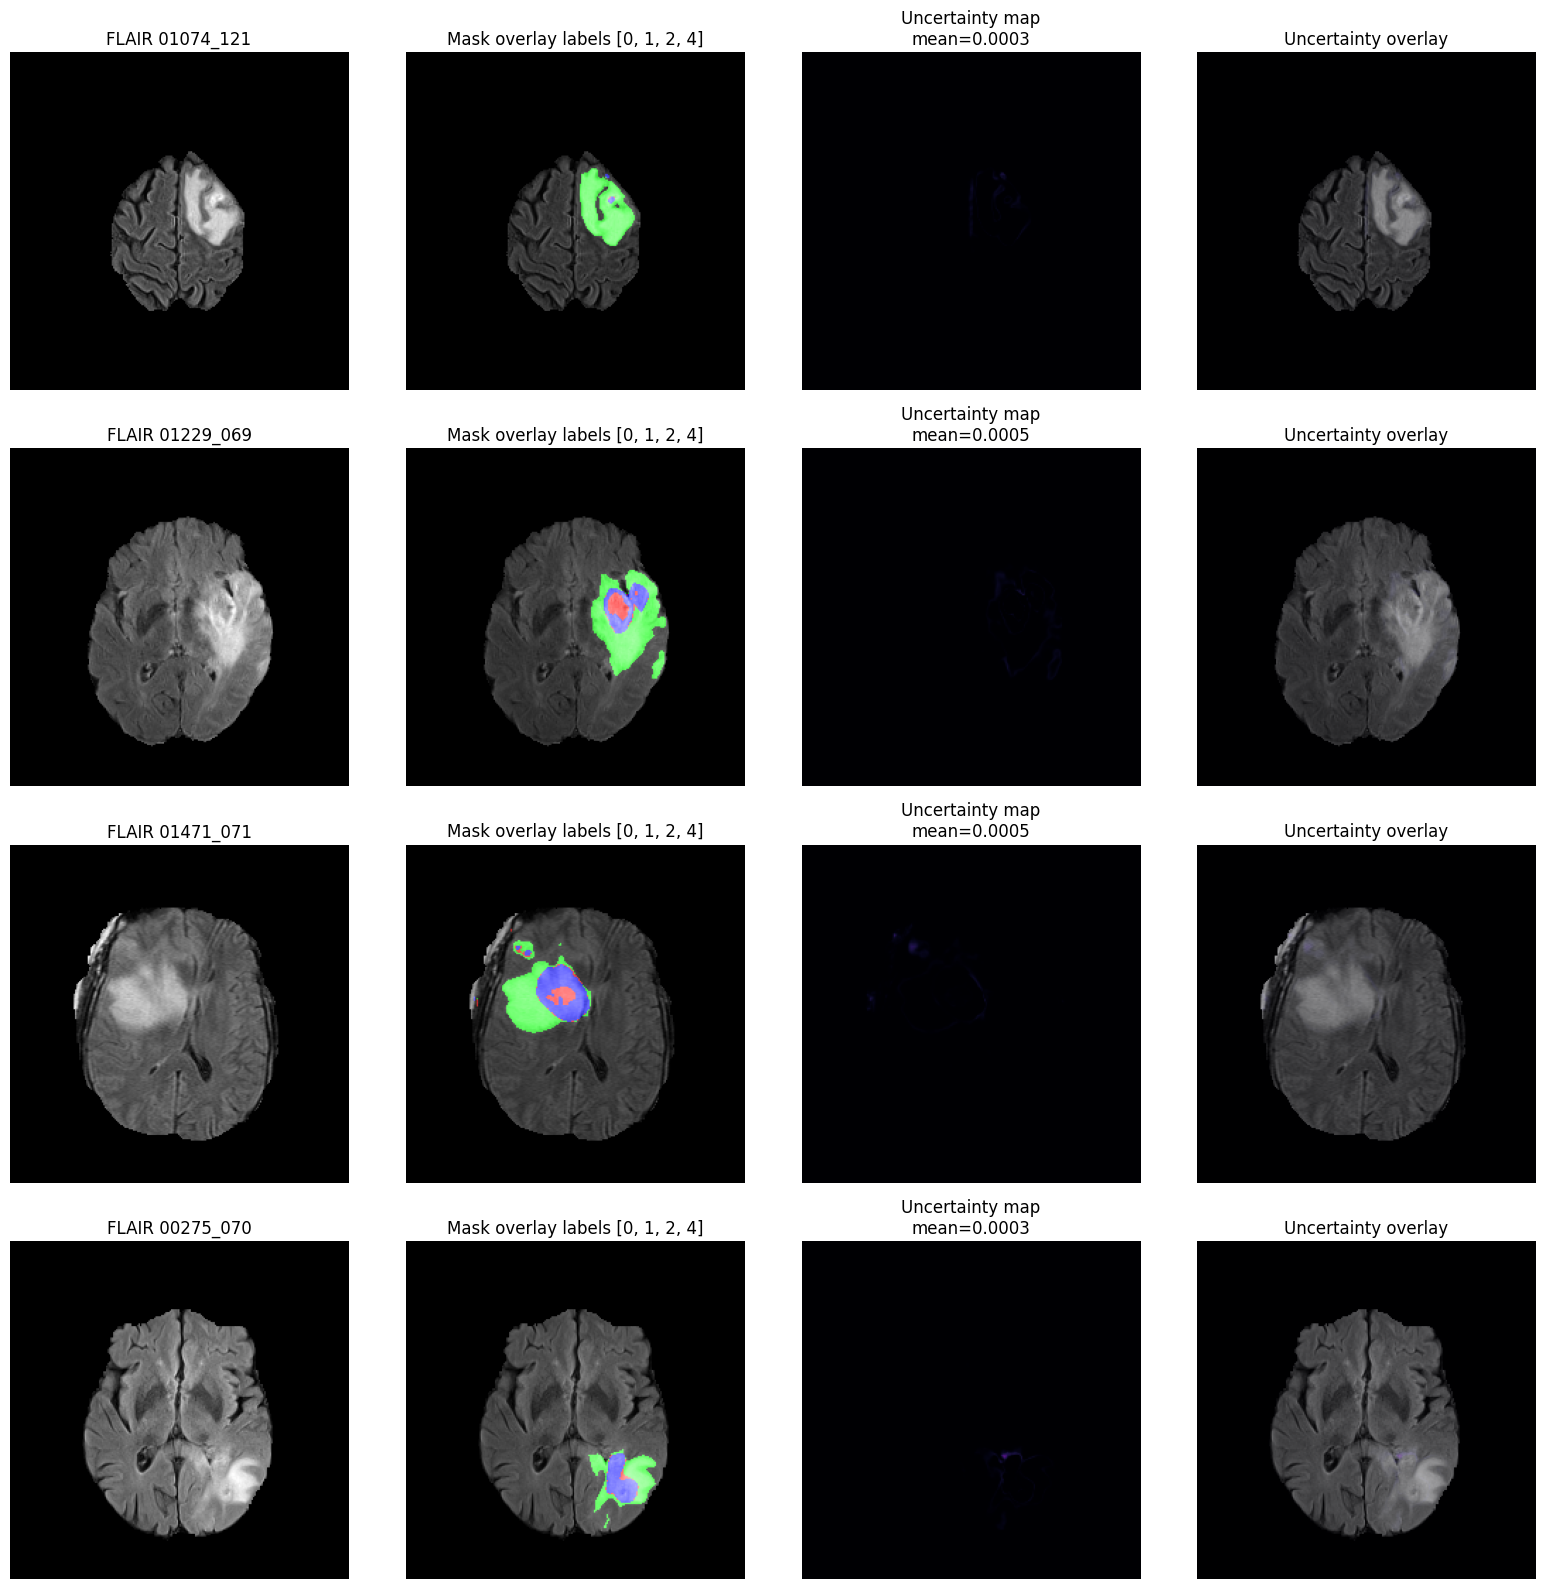

Sample uncertainty visualization saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/visualizations/sample_uncertainty_overlay.png


In [ ]:
def normalize_for_display(image: np.ndarray):
    image = image.astype(np.float32)
    mn, mx = image.min(), image.max()

    if mx > mn:
        return (image - mn) / (mx - mn)

    return np.zeros_like(image, dtype=np.float32)


def load_uncertainty_map_from_payload(payload, slice_index):
    if "uncertainty_maps_float16" in payload:
        return payload["uncertainty_maps_float16"][slice_index].float().numpy()

    if "uncertainty_maps_uint8" in payload:
        return payload["uncertainty_maps_uint8"][slice_index].float().numpy() / 255.0

    raise ValueError("No uncertainty map found in payload.")


def colorize_mask(seg_mask: np.ndarray):
    rgb = np.zeros((seg_mask.shape[0], seg_mask.shape[1], 3), dtype=np.float32)

    rgb[seg_mask == 1] = [1.0, 0.0, 0.0]  # NCR/NET
    rgb[seg_mask == 2] = [0.0, 1.0, 0.0]  # edema
    rgb[seg_mask == 4] = [0.0, 0.0, 1.0]  # enhancing

    return rgb


def visualize_uncertainty_samples(sample_count=4):
    uncertainty_files = sorted(UNCERTAINTY_SAVE_DIR.glob("*.pt"))

    if not uncertainty_files:
        print("No uncertainty files found.")
        return

    selected_examples = []

    shuffled_files = uncertainty_files.copy()
    random.shuffle(shuffled_files)

    for uncertainty_file in shuffled_files:
        payload = torch.load(uncertainty_file, map_location="cpu")
        unique_ids = payload.get("unique_ids", [])

        if len(unique_ids) == 0:
            continue

        slice_index = random.randint(0, len(unique_ids) - 1)
        selected_examples.append((uncertainty_file, payload, slice_index))

        if len(selected_examples) >= sample_count:
            break

    if not selected_examples:
        print("No valid uncertainty examples found.")
        return

    fig, axes = plt.subplots(len(selected_examples), 4, figsize=(16, 4 * len(selected_examples)))

    if len(selected_examples) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, (uncertainty_file, payload, slice_index) in enumerate(selected_examples):
        unique_id = payload["unique_ids"][slice_index]
        patient_id, slice_id = unique_id.split("_")

        flair_path = image_path_for_modality(DATASET_ROOT, "flair", patient_id, slice_id)
        flair = read_grayscale_png(flair_path, IMAGE_SIZE)
        flair_display = normalize_for_display(flair)

        seg_mask = load_phase1_mask(unique_id)
        seg_rgb = colorize_mask(seg_mask)

        uncertainty = load_uncertainty_map_from_payload(payload, slice_index)

        base_rgb = np.stack([flair_display] * 3, axis=-1)
        heatmap = plt.cm.magma(uncertainty)[..., :3]

        uncertainty_overlay = np.clip(0.65 * base_rgb + 0.55 * heatmap, 0, 1)
        mask_overlay = np.clip(0.70 * base_rgb + 0.60 * seg_rgb, 0, 1)

        axes[row_index, 0].imshow(flair_display, cmap="gray")
        axes[row_index, 0].set_title(f"FLAIR {unique_id}")
        axes[row_index, 0].axis("off")

        axes[row_index, 1].imshow(mask_overlay)
        axes[row_index, 1].set_title(f"Mask overlay labels {np.unique(seg_mask).tolist()}")
        axes[row_index, 1].axis("off")

        axes[row_index, 2].imshow(uncertainty, cmap="magma", vmin=0, vmax=1)
        axes[row_index, 2].set_title(f"Uncertainty map\nmean={uncertainty.mean():.4f}")
        axes[row_index, 2].axis("off")

        axes[row_index, 3].imshow(uncertainty_overlay)
        axes[row_index, 3].set_title("Uncertainty overlay")
        axes[row_index, 3].axis("off")

    plt.tight_layout()
    plt.savefig(SAMPLE_UNCERTAINTY_VIS_PATH, dpi=150, bbox_inches="tight")
    plt.show()

    print("Sample uncertainty visualization saved:", SAMPLE_UNCERTAINTY_VIS_PATH)


visualize_uncertainty_samples(sample_count=4)


# Final Phase 2B Report


In [ ]:
uncertainty_files = sorted(UNCERTAINTY_SAVE_DIR.glob("*.pt"))
global_uncertainty_manifest_df = rebuild_global_uncertainty_manifest()

final_report = {
    "finished_at": now_string(),
    "phase": "Phase 2B - MC Dropout uncertainty map generation",
    "status": "complete_or_resume_ready",
    "mc_dropout_passes": MC_DROPOUT_PASSES,
    "uncertainty_files": len(uncertainty_files),
    "manifest_rows": int(len(global_uncertainty_manifest_df)) if len(global_uncertainty_manifest_df) else 0,
    "uncertainty_save_dir": str(UNCERTAINTY_SAVE_DIR),
    "global_uncertainty_manifest_path": str(GLOBAL_UNCERTAINTY_MANIFEST_PATH),
    "validation_summary_path": str(UNCERTAINTY_VALIDATION_SUMMARY_PATH),
    "sample_visualization_path": str(SAMPLE_UNCERTAINTY_VIS_PATH),
    "region_names": TOKEN_REGION_NAMES,
    "next_step": "Phase 2C - UGTM: token * (1 - region_uncertainty)",
    "note": (
        "For final research setting, MC_DROPOUT_PASSES should ideally be 20. "
        "If this was a smoke test with T=5, rerun with T=20. "
        "The safer resume checker will recompute T=5 patients when T=20 is selected."
    ),
}

atomic_write_json(PHASE2B_LOG_DIR / "final_phase2b_report.json", final_report)

print("=" * 80)
print("BrainTumorVQA Phase 2B Report")
print("=" * 80)
print("Status: complete or safely resumable")
print("MC Dropout passes:", MC_DROPOUT_PASSES)
print("Uncertainty patient files:", len(uncertainty_files))
print("Manifest rows:", len(global_uncertainty_manifest_df))
print("Uncertainty directory:", UNCERTAINTY_SAVE_DIR)
print("Global uncertainty manifest:", GLOBAL_UNCERTAINTY_MANIFEST_PATH)
print("Validation summary:", UNCERTAINTY_VALIDATION_SUMMARY_PATH)
print("Final report:", PHASE2B_LOG_DIR / "final_phase2b_report.json")
print("=" * 80)

if MAX_PATIENTS_PER_RUN is not None:
    print("\nSmoke test mode was active.")
    print("If outputs look correct, set:")
    print("MC_DROPOUT_PASSES = 20")
    print("MAX_PATIENTS_PER_RUN = None")
    print("OVERWRITE_EXISTING_UNCERTAINTY = False")
    print("Then rerun from the execution cell.")
else:
    print("\nFull Phase 2B processing attempted.")
    print("If Colab disconnected, rerun from the top. Existing same-T patient files will be skipped.")


Global uncertainty manifest saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/logs/global_uncertainty_manifest.csv
Rows: 79864
BrainTumorVQA Phase 2B Report
Status: complete or safely resumable
MC Dropout passes: 20
Uncertainty patient files: 1251
Manifest rows: 79864
Uncertainty directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/uncertainty_by_patient
Global uncertainty manifest: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/logs/global_uncertainty_manifest.csv
Validation summary: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/logs/uncertainty_validation_summary.json
Final report: /content/drive/MyDrive/AMIR Lab/Research Assistant 

# ============================================================
# BrainTumorVQA Phase 2C
# Uncertainty-Guided Token Modulation (UGTM)
#
# Input:
### Phase 2A region tokens
### Phase 2B region uncertainty scores
#
# Output:
###   Original tokens + uncertainty + modulation weights + modulated tokens
#
# UGTM Formula:
###   modulated_token_region = original_token_region * (1 - uncertainty_region)
# ============================================================

In [ ]:
!pip install -q pandas tqdm matplotlib

import os
import csv
import json
import time
import random
import warnings
import traceback
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
from tqdm.auto import tqdm

import torch

from google.colab import drive

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

print("Libraries loaded.")
print("PyTorch:", torch.__version__)


Libraries loaded.
PyTorch: 2.10.0+cu128


# Drive, Phase 2C Paths and Configuration Setup

In [ ]:
# drive.mount("/content/drive")

PROJECT_DRIVE_DIR = PROJECT_ROOT

# Phase 2A inputs
PHASE2A_DIR = PROJECT_DRIVE_DIR / "phase_2" / "p2a_region_tokens"
PHASE2A_TOKEN_DIR = PHASE2A_DIR / "tokens_by_patient"
PHASE2A_LOG_DIR = PHASE2A_DIR / "logs"
PHASE2A_GLOBAL_MANIFEST_PATH = PHASE2A_LOG_DIR / "global_token_manifest.csv"

# Phase 2B inputs
PHASE2B_DIR = PROJECT_DRIVE_DIR / "phase_2" / "p2b_mc_dropout_uncertainty"
PHASE2B_UNCERTAINTY_DIR = PHASE2B_DIR / "uncertainty_by_patient"
PHASE2B_LOG_DIR = PHASE2B_DIR / "logs"
PHASE2B_GLOBAL_MANIFEST_PATH = PHASE2B_LOG_DIR / "global_uncertainty_manifest.csv"

# Phase 2C outputs
PHASE2C_DIR = PROJECT_DRIVE_DIR / "phase_2" / "p2c_ugtm_modulated_tokens"
UGTM_SAVE_DIR = PHASE2C_DIR / "modulated_tokens_by_patient"
PHASE2C_LOG_DIR = PHASE2C_DIR / "logs"
PHASE2C_VIS_DIR = PHASE2C_DIR / "visualizations"
PATIENT_UGTM_DONE_DIR = PHASE2C_LOG_DIR / "patient_done"
PATIENT_UGTM_MANIFEST_DIR = PHASE2C_LOG_DIR / "patient_manifests"

for directory in [
    PHASE2C_DIR,
    UGTM_SAVE_DIR,
    PHASE2C_LOG_DIR,
    PHASE2C_VIS_DIR,
    PATIENT_UGTM_DONE_DIR,
    PATIENT_UGTM_MANIFEST_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

# Region order must match Phase 2A and Phase 2B exactly.
TOKEN_REGION_NAMES = [
    "edema",
    "ncr_net",
    "enhancing",
    "tumor",
    "context",
    "global",
]

TOKEN_DIM = 512
EXPECTED_REGION_COUNT = 6

UGTM_FORMULA = "token * (1 - uncertainty)"

# Keep False for resume safety.
OVERWRITE_EXISTING_UGTM = False

# Storage:
# float16 is recommended to reduce Drive storage.
# uncertainty and modulation weights are still saved as float32.
SAVE_MODULATED_TOKEN_DTYPE = "float16"   # "float16" or "float32"
SAVE_ORIGINAL_TOKEN_COPY = True          # per your choice: save both original and modulated

# Optional smoke test. Use None for full Phase 2C.
MAX_PATIENTS_PER_RUN = None

# Optional patient range split if needed.
PATIENT_START_INDEX = 0
PATIENT_END_INDEX = None

RUN_CONFIG_PATH = PHASE2C_LOG_DIR / "phase2c_ugtm_config.json"
GLOBAL_UGTM_MANIFEST_PATH = PHASE2C_LOG_DIR / "global_ugtm_manifest.csv"
UGTM_VALIDATION_SUMMARY_PATH = PHASE2C_LOG_DIR / "ugtm_validation_summary.json"
FINAL_PHASE2C_REPORT_PATH = PHASE2C_LOG_DIR / "final_phase2c_report.json"
SAMPLE_UGTM_STATS_VIS_PATH = PHASE2C_VIS_DIR / "sample_ugtm_token_norms.png"

assert PHASE2A_TOKEN_DIR.exists(), f"Phase 2A token directory not found: {PHASE2A_TOKEN_DIR}"
assert PHASE2B_UNCERTAINTY_DIR.exists(), f"Phase 2B uncertainty directory not found: {PHASE2B_UNCERTAINTY_DIR}"

print("Phase 2A token dir:", PHASE2A_TOKEN_DIR)
print("Phase 2B uncertainty dir:", PHASE2B_UNCERTAINTY_DIR)
print("Phase 2C UGTM output dir:", UGTM_SAVE_DIR)
print("UGTM formula:", UGTM_FORMULA)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Phase 2A token dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2a_region_tokens/tokens_by_patient
Phase 2B uncertainty dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2b_mc_dropout_uncertainty/uncertainty_by_patient
Phase 2C UGTM output dir: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/modulated_tokens_by_patient
UGTM formula: token * (1 - uncertainty)


# Persistence and Loading Helpers

In [ ]:
def now_string():
    return datetime.now().strftime("%Y-%m-%d %H:%M:%S")


def atomic_write_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", encoding="utf-8") as file:
        json.dump(data, file, indent=2)
    os.replace(temp_path, path)


def read_json(path: Path, default):
    if not path.exists():
        return default
    with open(path, "r", encoding="utf-8") as file:
        return json.load(file)


def atomic_torch_save(obj, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    torch.save(obj, temp_path)
    os.replace(temp_path, path)


def atomic_write_csv(path: Path, rows: list, fieldnames: list):
    path.parent.mkdir(parents=True, exist_ok=True)
    temp_path = path.with_suffix(path.suffix + ".tmp")
    with open(temp_path, "w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)
    os.replace(temp_path, path)


def safe_torch_load(path: Path, map_location="cpu"):
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def tensor_to_save_dtype(tensor: torch.Tensor):
    if SAVE_MODULATED_TOKEN_DTYPE == "float16":
        return tensor.half()
    if SAVE_MODULATED_TOKEN_DTYPE == "float32":
        return tensor.float()
    raise ValueError(f"Unsupported SAVE_MODULATED_TOKEN_DTYPE: {SAVE_MODULATED_TOKEN_DTYPE}")


phase2c_config = {
    "created_at": now_string(),
    "phase": "Phase 2C - Uncertainty-Guided Token Modulation",
    "phase2a_token_dir": str(PHASE2A_TOKEN_DIR),
    "phase2b_uncertainty_dir": str(PHASE2B_UNCERTAINTY_DIR),
    "ugtm_save_dir": str(UGTM_SAVE_DIR),
    "region_names": TOKEN_REGION_NAMES,
    "token_dim": TOKEN_DIM,
    "formula": UGTM_FORMULA,
    "modulation_weight": "1 - uncertainty",
    "uncertainty_clamp_range": "[0, 1]",
    "save_modulated_token_dtype": SAVE_MODULATED_TOKEN_DTYPE,
    "save_original_token_copy": SAVE_ORIGINAL_TOKEN_COPY,
    "overwrite_existing_ugtm": OVERWRITE_EXISTING_UGTM,
    "note": (
        "Original tokens are copied from Phase 2A. Region uncertainty is copied from Phase 2B. "
        "Modulated tokens are computed by multiplying each region token with its scalar reliability weight."
    ),
}

atomic_write_json(RUN_CONFIG_PATH, phase2c_config)

print("Phase 2C config saved:", RUN_CONFIG_PATH)


Phase 2C config saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/logs/phase2c_ugtm_config.json


# Inspect Phase 2A and Phase 2B Availability

In [ ]:
phase2a_token_files = sorted(PHASE2A_TOKEN_DIR.glob("*.pt"))
phase2b_uncertainty_files = sorted(PHASE2B_UNCERTAINTY_DIR.glob("*.pt"))

phase2a_patient_ids = {path.stem for path in phase2a_token_files}
phase2b_patient_ids = {path.stem for path in phase2b_uncertainty_files}

common_patient_ids = sorted(phase2a_patient_ids & phase2b_patient_ids)
missing_phase2b = sorted(phase2a_patient_ids - phase2b_patient_ids)
missing_phase2a = sorted(phase2b_patient_ids - phase2a_patient_ids)

print("Phase 2A token files:", len(phase2a_token_files))
print("Phase 2B uncertainty files:", len(phase2b_uncertainty_files))
print("Common patients ready for UGTM:", len(common_patient_ids))
print("Patients with Phase 2A but missing Phase 2B:", len(missing_phase2b))
print("Patients with Phase 2B but missing Phase 2A:", len(missing_phase2a))

if PHASE2A_GLOBAL_MANIFEST_PATH.exists():
    phase2a_manifest = pd.read_csv(PHASE2A_GLOBAL_MANIFEST_PATH)
    print("Phase 2A global manifest rows:", len(phase2a_manifest))
else:
    print("Warning: Phase 2A global manifest not found:", PHASE2A_GLOBAL_MANIFEST_PATH)

if PHASE2B_GLOBAL_MANIFEST_PATH.exists():
    phase2b_manifest = pd.read_csv(PHASE2B_GLOBAL_MANIFEST_PATH)
    print("Phase 2B global manifest rows:", len(phase2b_manifest))
else:
    print("Warning: Phase 2B global manifest not found:", PHASE2B_GLOBAL_MANIFEST_PATH)

availability_report = {
    "checked_at": now_string(),
    "phase2a_token_files": len(phase2a_token_files),
    "phase2b_uncertainty_files": len(phase2b_uncertainty_files),
    "common_patients_ready": len(common_patient_ids),
    "missing_phase2b_count": len(missing_phase2b),
    "missing_phase2a_count": len(missing_phase2a),
    "missing_phase2b_examples": missing_phase2b[:20],
    "missing_phase2a_examples": missing_phase2a[:20],
}

atomic_write_json(PHASE2C_LOG_DIR / "phase2c_input_availability.json", availability_report)


Phase 2A token files: 1251
Phase 2B uncertainty files: 1251
Common patients ready for UGTM: 1251
Patients with Phase 2A but missing Phase 2B: 0
Patients with Phase 2B but missing Phase 2A: 0
Phase 2A global manifest rows: 79864
Phase 2B global manifest rows: 79864


# UGTM Core Functions

In [ ]:
def phase2a_token_file_path(patient_id: str):
    return PHASE2A_TOKEN_DIR / f"{patient_id}.pt"


def phase2b_uncertainty_file_path(patient_id: str):
    return PHASE2B_UNCERTAINTY_DIR / f"{patient_id}.pt"


def patient_ugtm_file_path(patient_id: str):
    return UGTM_SAVE_DIR / f"{patient_id}.pt"


def patient_done_path(patient_id: str):
    return PATIENT_UGTM_DONE_DIR / f"{patient_id}.json"


def patient_manifest_path(patient_id: str):
    return PATIENT_UGTM_MANIFEST_DIR / f"{patient_id}.csv"


def config_matches_done(done_data: dict):
    return (
        done_data.get("formula") == UGTM_FORMULA
        and done_data.get("region_names") == TOKEN_REGION_NAMES
        and int(done_data.get("token_dim", -1)) == TOKEN_DIM
        and done_data.get("save_modulated_token_dtype") == SAVE_MODULATED_TOKEN_DTYPE
    )


def patient_already_done(patient_id: str):
    if OVERWRITE_EXISTING_UGTM:
        return False

    ugtm_file = patient_ugtm_file_path(patient_id)
    done_file = patient_done_path(patient_id)
    manifest_file = patient_manifest_path(patient_id)

    if not (ugtm_file.exists() and done_file.exists() and manifest_file.exists()):
        return False

    try:
        done_data = read_json(done_file, {})
        if not config_matches_done(done_data):
            return False

        payload = safe_torch_load(ugtm_file, map_location="cpu")

        if payload.get("formula") != UGTM_FORMULA:
            return False
        if payload.get("region_names") != TOKEN_REGION_NAMES:
            return False
        if int(payload.get("token_dim", -1)) != TOKEN_DIM:
            return False

        return True

    except Exception:
        return False


def validate_payload_alignment(patient_id: str, token_payload: dict, uncertainty_payload: dict):
    token_unique_ids = list(token_payload["unique_ids"])
    uncertainty_unique_ids = list(uncertainty_payload["unique_ids"])

    if token_unique_ids != uncertainty_unique_ids:
        raise ValueError(
            f"Unique ID mismatch for patient {patient_id}: "
            f"Phase2A has {len(token_unique_ids)} IDs, Phase2B has {len(uncertainty_unique_ids)} IDs."
        )

    tokens = token_payload["tokens"]
    region_uncertainty = uncertainty_payload["region_uncertainty"]

    if len(tokens.shape) != 3:
        raise ValueError(f"Bad token shape for patient {patient_id}: {list(tokens.shape)}")

    if tokens.shape[1] != EXPECTED_REGION_COUNT or tokens.shape[2] != TOKEN_DIM:
        raise ValueError(f"Unexpected token shape for patient {patient_id}: {list(tokens.shape)}")

    if len(region_uncertainty.shape) != 2:
        raise ValueError(
            f"Bad uncertainty shape for patient {patient_id}: {list(region_uncertainty.shape)}"
        )

    if region_uncertainty.shape[0] != tokens.shape[0] or region_uncertainty.shape[1] != EXPECTED_REGION_COUNT:
        raise ValueError(
            f"Token/uncertainty shape mismatch for patient {patient_id}: "
            f"tokens={list(tokens.shape)}, uncertainty={list(region_uncertainty.shape)}"
        )

    if token_payload.get("token_names", TOKEN_REGION_NAMES) != TOKEN_REGION_NAMES:
        raise ValueError(
            f"Phase2A token_names mismatch for patient {patient_id}: "
            f"{token_payload.get('token_names')}"
        )

    if uncertainty_payload.get("region_names", TOKEN_REGION_NAMES) != TOKEN_REGION_NAMES:
        raise ValueError(
            f"Phase2B region_names mismatch for patient {patient_id}: "
            f"{uncertainty_payload.get('region_names')}"
        )

    return True


def compute_ugtm_for_patient(patient_id: str, token_payload: dict, uncertainty_payload: dict):
    validate_payload_alignment(patient_id, token_payload, uncertainty_payload)

    original_tokens = token_payload["tokens"].float()                    # [N, 6, 512]
    region_uncertainty = uncertainty_payload["region_uncertainty"].float() # [N, 6]

    region_uncertainty = torch.nan_to_num(
        region_uncertainty,
        nan=0.0,
        posinf=1.0,
        neginf=0.0,
    )

    region_uncertainty = torch.clamp(region_uncertainty, 0.0, 1.0)
    modulation_weights = 1.0 - region_uncertainty                       # [N, 6]

    modulated_tokens = original_tokens * modulation_weights.unsqueeze(-1)

    if torch.isnan(original_tokens).any() or torch.isinf(original_tokens).any():
        raise ValueError(f"Original tokens contain NaN/Inf for patient {patient_id}")

    if torch.isnan(modulated_tokens).any() or torch.isinf(modulated_tokens).any():
        raise ValueError(f"Modulated tokens contain NaN/Inf for patient {patient_id}")

    if torch.isnan(modulation_weights).any() or torch.isinf(modulation_weights).any():
        raise ValueError(f"Modulation weights contain NaN/Inf for patient {patient_id}")

    if (modulation_weights < 0).any() or (modulation_weights > 1).any():
        raise ValueError(f"Modulation weights outside [0,1] for patient {patient_id}")

    return original_tokens, region_uncertainty, modulation_weights, modulated_tokens


print("UGTM core functions ready.")


UGTM core functions ready.


# Patient-Level UGTM Processing with Resume Support

In [ ]:
MANIFEST_FIELDS = [
    "patient_id",
    "slice_id",
    "unique_id",
    "tumor_slice_csv",
    "ugtm_file",
    "slice_index_in_ugtm_file",
    "token_shape",
    "mc_dropout_passes",
    "edema_uncertainty",
    "ncr_net_uncertainty",
    "enhancing_uncertainty",
    "tumor_uncertainty",
    "context_uncertainty",
    "global_uncertainty",
    "edema_weight",
    "ncr_net_weight",
    "enhancing_weight",
    "tumor_weight",
    "context_weight",
    "global_weight",
    "edema_present",
    "ncr_net_present",
    "enhancing_present",
    "tumor_present",
    "context_present",
    "global_present",
    "edema_original_norm",
    "ncr_net_original_norm",
    "enhancing_original_norm",
    "tumor_original_norm",
    "context_original_norm",
    "global_original_norm",
    "edema_modulated_norm",
    "ncr_net_modulated_norm",
    "enhancing_modulated_norm",
    "tumor_modulated_norm",
    "context_modulated_norm",
    "global_modulated_norm",
    "saved_at",
]


def process_one_patient_for_ugtm(patient_id: str):
    started_at = time.time()

    if patient_already_done(patient_id):
        done_data = read_json(patient_done_path(patient_id), {})
        return {
            "patient_id": patient_id,
            "status": "skipped_already_done",
            "saved_slices": 0,
            "existing_slices": int(done_data.get("saved_slices", 0)),
            "elapsed_sec": round(time.time() - started_at, 2),
        }

    token_file = phase2a_token_file_path(patient_id)
    uncertainty_file = phase2b_uncertainty_file_path(patient_id)

    if not token_file.exists():
        return {
            "patient_id": patient_id,
            "status": "skipped_missing_phase2a",
            "saved_slices": 0,
            "elapsed_sec": round(time.time() - started_at, 2),
        }

    if not uncertainty_file.exists():
        return {
            "patient_id": patient_id,
            "status": "skipped_missing_phase2b",
            "saved_slices": 0,
            "elapsed_sec": round(time.time() - started_at, 2),
        }

    token_payload = safe_torch_load(token_file, map_location="cpu")
    uncertainty_payload = safe_torch_load(uncertainty_file, map_location="cpu")

    original_tokens, region_uncertainty, modulation_weights, modulated_tokens = compute_ugtm_for_patient(
        patient_id,
        token_payload,
        uncertainty_payload,
    )

    unique_ids = list(token_payload["unique_ids"])
    slice_ids = list(token_payload.get("slice_ids", uncertainty_payload.get("slice_ids", [])))

    if len(slice_ids) != len(unique_ids):
        slice_ids = [unique_id.split("_")[1] for unique_id in unique_ids]

    tumor_slice_csv = list(
        token_payload.get(
            "tumor_slice_csv",
            uncertainty_payload.get("tumor_slice_csv", [None] * len(unique_ids)),
        )
    )

    if len(tumor_slice_csv) != len(unique_ids):
        tumor_slice_csv = [None] * len(unique_ids)

    region_present = uncertainty_payload.get(
        "region_present",
        token_payload.get("region_present", torch.ones(len(unique_ids), EXPECTED_REGION_COUNT).bool()),
    ).bool()

    region_area_pixels = uncertainty_payload.get(
        "region_area_pixels",
        token_payload.get("region_area_pixels", torch.zeros(len(unique_ids), EXPECTED_REGION_COUNT).long()),
    ).long()

    mc_dropout_passes = int(uncertainty_payload.get("mc_dropout_passes", -1))

    original_norms = torch.linalg.vector_norm(original_tokens.float(), dim=-1)      # [N, 6]
    modulated_norms = torch.linalg.vector_norm(modulated_tokens.float(), dim=-1)    # [N, 6]

    payload = {
        "patient_id": patient_id,
        "created_at": now_string(),
        "formula": UGTM_FORMULA,
        "region_names": TOKEN_REGION_NAMES,
        "token_dim": TOKEN_DIM,
        "unique_ids": unique_ids,
        "slice_ids": slice_ids,
        "tumor_slice_csv": tumor_slice_csv,
        "mc_dropout_passes": mc_dropout_passes,
        "original_tokens": tensor_to_save_dtype(original_tokens) if SAVE_ORIGINAL_TOKEN_COPY else None,
        "region_uncertainty": region_uncertainty.float(),
        "modulation_weights": modulation_weights.float(),
        "modulated_tokens": tensor_to_save_dtype(modulated_tokens),
        "region_present": region_present,
        "region_area_pixels": region_area_pixels,
        "original_token_norms": original_norms.float(),
        "modulated_token_norms": modulated_norms.float(),
        "phase2a_token_file": str(token_file),
        "phase2b_uncertainty_file": str(uncertainty_file),
        "save_modulated_token_dtype": SAVE_MODULATED_TOKEN_DTYPE,
        "save_original_token_copy": SAVE_ORIGINAL_TOKEN_COPY,
    }

    ugtm_file = patient_ugtm_file_path(patient_id)
    atomic_torch_save(payload, ugtm_file)

    manifest_rows = []

    for slice_index, unique_id in enumerate(unique_ids):
        uncertainty_values = region_uncertainty[slice_index].tolist()
        weight_values = modulation_weights[slice_index].tolist()
        present_values = region_present[slice_index].tolist()
        original_norm_values = original_norms[slice_index].tolist()
        modulated_norm_values = modulated_norms[slice_index].tolist()

        manifest_rows.append(
            {
                "patient_id": patient_id,
                "slice_id": slice_ids[slice_index],
                "unique_id": unique_id,
                "tumor_slice_csv": tumor_slice_csv[slice_index],
                "ugtm_file": str(ugtm_file),
                "slice_index_in_ugtm_file": slice_index,
                "token_shape": json.dumps([EXPECTED_REGION_COUNT, TOKEN_DIM]),
                "mc_dropout_passes": mc_dropout_passes,
                "edema_uncertainty": uncertainty_values[0],
                "ncr_net_uncertainty": uncertainty_values[1],
                "enhancing_uncertainty": uncertainty_values[2],
                "tumor_uncertainty": uncertainty_values[3],
                "context_uncertainty": uncertainty_values[4],
                "global_uncertainty": uncertainty_values[5],
                "edema_weight": weight_values[0],
                "ncr_net_weight": weight_values[1],
                "enhancing_weight": weight_values[2],
                "tumor_weight": weight_values[3],
                "context_weight": weight_values[4],
                "global_weight": weight_values[5],
                "edema_present": present_values[0],
                "ncr_net_present": present_values[1],
                "enhancing_present": present_values[2],
                "tumor_present": present_values[3],
                "context_present": present_values[4],
                "global_present": present_values[5],
                "edema_original_norm": original_norm_values[0],
                "ncr_net_original_norm": original_norm_values[1],
                "enhancing_original_norm": original_norm_values[2],
                "tumor_original_norm": original_norm_values[3],
                "context_original_norm": original_norm_values[4],
                "global_original_norm": original_norm_values[5],
                "edema_modulated_norm": modulated_norm_values[0],
                "ncr_net_modulated_norm": modulated_norm_values[1],
                "enhancing_modulated_norm": modulated_norm_values[2],
                "tumor_modulated_norm": modulated_norm_values[3],
                "context_modulated_norm": modulated_norm_values[4],
                "global_modulated_norm": modulated_norm_values[5],
                "saved_at": now_string(),
            }
        )

    atomic_write_csv(patient_manifest_path(patient_id), manifest_rows, MANIFEST_FIELDS)

    done_payload = {
        "patient_id": patient_id,
        "status": "complete",
        "saved_slices": len(unique_ids),
        "ugtm_file": str(ugtm_file),
        "manifest_file": str(patient_manifest_path(patient_id)),
        "formula": UGTM_FORMULA,
        "region_names": TOKEN_REGION_NAMES,
        "token_dim": TOKEN_DIM,
        "mc_dropout_passes": mc_dropout_passes,
        "save_modulated_token_dtype": SAVE_MODULATED_TOKEN_DTYPE,
        "save_original_token_copy": SAVE_ORIGINAL_TOKEN_COPY,
        "finished_at": now_string(),
        "elapsed_sec": round(time.time() - started_at, 2),
    }

    atomic_write_json(patient_done_path(patient_id), done_payload)

    return done_payload


print("Patient UGTM processing function ready.")


Patient UGTM processing function ready.


# Execute Phase 2C UGTM
# Clean Resume-Safe Version

In [ ]:
all_patient_ids = sorted(common_patient_ids)

all_patient_ids = all_patient_ids[PATIENT_START_INDEX:PATIENT_END_INDEX]

if MAX_PATIENTS_PER_RUN is not None:
    all_patient_ids = all_patient_ids[:MAX_PATIENTS_PER_RUN]

print("Patients selected for UGTM:", len(all_patient_ids))
print("First patients:", all_patient_ids[:10])
print("PATIENT_START_INDEX:", PATIENT_START_INDEX)
print("PATIENT_END_INDEX:", PATIENT_END_INDEX)
print("MAX_PATIENTS_PER_RUN:", MAX_PATIENTS_PER_RUN)
print("OVERWRITE_EXISTING_UGTM:", OVERWRITE_EXISTING_UGTM)

run_started = time.time()
run_results = []

total_saved_slices = 0
total_existing_slices = 0
total_missing_phase2a = 0
total_missing_phase2b = 0
total_failed_patients = 0

SHOW_FIRST_N = 10

progress_bar = tqdm(
    all_patient_ids,
    desc="Applying UGTM",
    dynamic_ncols=True,
    leave=True,
)

for patient_index, patient_id in enumerate(progress_bar, start=1):
    try:
        result = process_one_patient_for_ugtm(patient_id)
        run_results.append(result)

        status = result.get("status", "")

        saved_slices = int(result.get("saved_slices", 0))
        existing_slices = int(result.get("existing_slices", 0))

        total_saved_slices += saved_slices
        total_existing_slices += existing_slices

        if status == "skipped_missing_phase2a":
            total_missing_phase2a += 1
        if status == "skipped_missing_phase2b":
            total_missing_phase2b += 1

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": status,
                "saved": total_saved_slices,
                "existing": total_existing_slices,
                "failed": total_failed_patients,
            }
        )

        if patient_index <= SHOW_FIRST_N:
            tqdm.write(
                f"[{patient_index:04d}/{len(all_patient_ids)}] "
                f"Patient {patient_id} | {status} | "
                f"saved_slices={saved_slices} | existing_slices={existing_slices} | "
                f"time={result.get('elapsed_sec', 0)}s"
            )

        elif patient_index == SHOW_FIRST_N + 1:
            tqdm.write(
                f"Showing only first {SHOW_FIRST_N} patient logs now. "
                "Progress continues in the live progress bar..."
            )

    except Exception as error:
        error_payload = {
            "patient_id": patient_id,
            "status": "failed",
            "error": str(error),
            "traceback": traceback.format_exc(),
            "failed_at": now_string(),
        }

        atomic_write_json(PHASE2C_LOG_DIR / "patient_errors" / f"{patient_id}.json", error_payload)
        run_results.append(error_payload)

        total_failed_patients += 1

        progress_bar.set_postfix(
            {
                "patient": patient_id,
                "status": "failed",
                "saved": total_saved_slices,
                "existing": total_existing_slices,
                "failed": total_failed_patients,
            }
        )

        tqdm.write(f"Patient {patient_id} failed: {error}")

progress_bar.close()

run_elapsed = round((time.time() - run_started) / 60, 2)

run_summary = {
    "finished_at": now_string(),
    "patients_attempted": len(all_patient_ids),
    "run_elapsed_minutes": run_elapsed,
    "formula": UGTM_FORMULA,
    "total_saved_slices": total_saved_slices,
    "total_existing_slices": total_existing_slices,
    "total_missing_phase2a": total_missing_phase2a,
    "total_missing_phase2b": total_missing_phase2b,
    "total_failed_patients": total_failed_patients,
    "results": run_results,
}

atomic_write_json(PHASE2C_LOG_DIR / "latest_phase2c_run_summary.json", run_summary)

print("\nPhase 2C UGTM run finished.")
print("Elapsed minutes:", run_elapsed)
print("New UGTM slices:", total_saved_slices)
print("Existing UGTM slices skipped:", total_existing_slices)
print("Missing Phase 2A patients:", total_missing_phase2a)
print("Missing Phase 2B patients:", total_missing_phase2b)
print("Failed patients:", total_failed_patients)
print("UGTM directory:", UGTM_SAVE_DIR)
print("Latest run summary:", PHASE2C_LOG_DIR / "latest_phase2c_run_summary.json")


Patients selected for UGTM: 1251
First patients: ['00000', '00002', '00003', '00005', '00006', '00008', '00009', '00011', '00012', '00014']
PATIENT_START_INDEX: 0
PATIENT_END_INDEX: None
MAX_PATIENTS_PER_RUN: None
OVERWRITE_EXISTING_UGTM: False


Applying UGTM:   0%|          | 0/1251 [00:00<?, ?it/s]

[0001/1251] Patient 00000 | skipped_already_done | saved_slices=0 | existing_slices=47 | time=0.02s
[0002/1251] Patient 00002 | skipped_already_done | saved_slices=0 | existing_slices=86 | time=0.02s
[0003/1251] Patient 00003 | skipped_already_done | saved_slices=0 | existing_slices=60 | time=0.03s
[0004/1251] Patient 00005 | skipped_already_done | saved_slices=0 | existing_slices=64 | time=0.02s
[0005/1251] Patient 00006 | skipped_already_done | saved_slices=0 | existing_slices=68 | time=0.02s
[0006/1251] Patient 00008 | skipped_already_done | saved_slices=0 | existing_slices=39 | time=0.01s
[0007/1251] Patient 00009 | skipped_already_done | saved_slices=0 | existing_slices=60 | time=0.02s
[0008/1251] Patient 00011 | skipped_already_done | saved_slices=0 | existing_slices=61 | time=0.02s
[0009/1251] Patient 00012 | skipped_already_done | saved_slices=0 | existing_slices=81 | time=0.02s
[0010/1251] Patient 00014 | skipped_already_done | saved_slices=0 | existing_slices=51 | time=0.02s


# Rebuild Global UGTM Manifest

In [ ]:
def rebuild_global_ugtm_manifest():
    manifest_files = sorted(PATIENT_UGTM_MANIFEST_DIR.glob("*.csv"))

    if not manifest_files:
        print("No patient UGTM manifests found.")
        return pd.DataFrame()

    dfs = []

    for path in manifest_files:
        try:
            df = pd.read_csv(path)
            dfs.append(df)
        except Exception as error:
            print(f"Could not read manifest {path}: {error}")

    if not dfs:
        return pd.DataFrame()

    global_df = pd.concat(dfs, ignore_index=True)
    global_df = global_df.drop_duplicates(subset=["unique_id"], keep="last")
    global_df = global_df.sort_values(["patient_id", "slice_id"]).reset_index(drop=True)

    global_df.to_csv(GLOBAL_UGTM_MANIFEST_PATH, index=False)

    print("Global UGTM manifest saved:", GLOBAL_UGTM_MANIFEST_PATH)
    print("Rows:", len(global_df))

    return global_df


global_ugtm_manifest_df = rebuild_global_ugtm_manifest()

if len(global_ugtm_manifest_df) > 0:
    display(global_ugtm_manifest_df.head())


Global UGTM manifest saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/logs/global_ugtm_manifest.csv
Rows: 79864


,patient_id,slice_id,unique_id,tumor_slice_csv,ugtm_file,slice_index_in_ugtm_file,token_shape,mc_dropout_passes,edema_uncertainty,ncr_net_uncertainty,...,tumor_original_norm,context_original_norm,global_original_norm,edema_modulated_norm,ncr_net_modulated_norm,enhancing_modulated_norm,tumor_modulated_norm,context_modulated_norm,global_modulated_norm,saved_at
0,0,49,00000_049,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,0,"[6, 512]",20,0.045768,0.000000,...,0.000000,0.000000,44.286823,0.0,0.000000,0.000000,0.000000,0.000000,44.236214,2026-04-17 16:59:54
1,0,50,00000_050,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,1,"[6, 512]",20,0.053225,0.080099,...,0.000000,47.361629,41.368084,0.0,0.000000,0.000000,0.000000,46.587612,41.285522,2026-04-17 16:59:54
2,0,51,00000_051,0,/content/drive/MyDrive/AMIR Lab/Research Assis...,2,"[6, 512]",20,0.042999,0.073363,...,48.045998,54.310600,42.193245,0.0,44.521206,46.665867,46.164783,53.815369,42.114838,2026-04-17 16:59:54
3,0,52,00000_052,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,3,"[6, 512]",20,0.033497,0.062273,...,44.611000,52.436382,41.838882,0.0,0.000000,43.956867,43.586292,51.893188,41.765072,2026-04-17 16:59:54
4,0,53,00000_053,1,/content/drive/MyDrive/AMIR Lab/Research Assis...,4,"[6, 512]",20,0.035751,0.052400,...,48.962025,54.820492,43.199562,0.0,51.947880,46.388298,48.018791,54.144218,43.106010,2026-04-17 16:59:54


# Validate Saved UGTM Outputs

In [ ]:
def validate_ugtm_files(max_files_to_scan=None):
    ugtm_files = sorted(UGTM_SAVE_DIR.glob("*.pt"))

    if max_files_to_scan is not None:
        ugtm_files = ugtm_files[:max_files_to_scan]

    scanned_files = 0
    total_slices = 0
    bad_files = []

    uncertainty_sums = {name: 0.0 for name in TOKEN_REGION_NAMES}
    uncertainty_counts = {name: 0 for name in TOKEN_REGION_NAMES}

    weight_sums = {name: 0.0 for name in TOKEN_REGION_NAMES}
    weight_counts = {name: 0 for name in TOKEN_REGION_NAMES}

    original_norm_sums = {name: 0.0 for name in TOKEN_REGION_NAMES}
    modulated_norm_sums = {name: 0.0 for name in TOKEN_REGION_NAMES}
    norm_counts = {name: 0 for name in TOKEN_REGION_NAMES}

    pass_counts_seen = {}

    for path in tqdm(ugtm_files, desc="Validating UGTM files"):
        try:
            payload = safe_torch_load(path, map_location="cpu")

            modulated_tokens = payload["modulated_tokens"].float()
            region_uncertainty = payload["region_uncertainty"].float()
            modulation_weights = payload["modulation_weights"].float()
            region_present = payload["region_present"].bool()

            if SAVE_ORIGINAL_TOKEN_COPY and payload.get("original_tokens") is not None:
                original_tokens = payload["original_tokens"].float()
            else:
                original_tokens = None

            if len(modulated_tokens.shape) != 3:
                bad_files.append({"file": str(path), "reason": f"bad_modulated_shape_{list(modulated_tokens.shape)}"})
                continue

            if modulated_tokens.shape[1] != EXPECTED_REGION_COUNT or modulated_tokens.shape[2] != TOKEN_DIM:
                bad_files.append({"file": str(path), "reason": f"unexpected_modulated_shape_{list(modulated_tokens.shape)}"})
                continue

            if region_uncertainty.shape != modulation_weights.shape:
                bad_files.append({"file": str(path), "reason": "uncertainty_weight_shape_mismatch"})
                continue

            if region_uncertainty.shape != modulated_tokens.shape[:2]:
                bad_files.append({"file": str(path), "reason": "token_uncertainty_shape_mismatch"})
                continue

            tensors_to_check = [modulated_tokens, region_uncertainty, modulation_weights]
            if original_tokens is not None:
                tensors_to_check.append(original_tokens)

            for tensor in tensors_to_check:
                if torch.isnan(tensor).any() or torch.isinf(tensor).any():
                    bad_files.append({"file": str(path), "reason": "nan_or_inf"})
                    raise ValueError("nan_or_inf")

            if (region_uncertainty < 0).any() or (region_uncertainty > 1).any():
                bad_files.append({"file": str(path), "reason": "uncertainty_outside_0_1"})
                continue

            if (modulation_weights < 0).any() or (modulation_weights > 1).any():
                bad_files.append({"file": str(path), "reason": "weights_outside_0_1"})
                continue

            if original_tokens is not None and original_tokens.shape != modulated_tokens.shape:
                bad_files.append({"file": str(path), "reason": "original_modulated_shape_mismatch"})
                continue

            mc_dropout_passes = int(payload.get("mc_dropout_passes", -1))
            pass_counts_seen[mc_dropout_passes] = pass_counts_seen.get(mc_dropout_passes, 0) + 1

            slice_count = len(payload["unique_ids"])
            total_slices += slice_count
            scanned_files += 1

            original_norms = payload.get("original_token_norms")
            modulated_norms = payload.get("modulated_token_norms")

            if original_norms is None and original_tokens is not None:
                original_norms = torch.linalg.vector_norm(original_tokens.float(), dim=-1)

            if modulated_norms is None:
                modulated_norms = torch.linalg.vector_norm(modulated_tokens.float(), dim=-1)

            original_norms = original_norms.float()
            modulated_norms = modulated_norms.float()

            for region_index, region_name in enumerate(TOKEN_REGION_NAMES):
                present_mask = region_present[:, region_index]
                count = int(present_mask.sum().item())

                if count > 0:
                    uncertainty_sums[region_name] += float(region_uncertainty[present_mask, region_index].sum().item())
                    uncertainty_counts[region_name] += count

                    weight_sums[region_name] += float(modulation_weights[present_mask, region_index].sum().item())
                    weight_counts[region_name] += count

                    original_norm_sums[region_name] += float(original_norms[present_mask, region_index].sum().item())
                    modulated_norm_sums[region_name] += float(modulated_norms[present_mask, region_index].sum().item())
                    norm_counts[region_name] += count

        except Exception as error:
            if not any(item["file"] == str(path) for item in bad_files):
                bad_files.append({"file": str(path), "reason": str(error)})

    mean_uncertainty = {}
    mean_weight = {}
    mean_original_norm = {}
    mean_modulated_norm = {}
    mean_suppression_percent = {}

    for region_name in TOKEN_REGION_NAMES:
        uncertainty_count = uncertainty_counts[region_name]
        weight_count = weight_counts[region_name]
        norm_count = norm_counts[region_name]

        mean_uncertainty[region_name] = (
            uncertainty_sums[region_name] / uncertainty_count if uncertainty_count > 0 else 0.0
        )

        mean_weight[region_name] = (
            weight_sums[region_name] / weight_count if weight_count > 0 else 0.0
        )

        mean_original_norm[region_name] = (
            original_norm_sums[region_name] / norm_count if norm_count > 0 else 0.0
        )

        mean_modulated_norm[region_name] = (
            modulated_norm_sums[region_name] / norm_count if norm_count > 0 else 0.0
        )

        if mean_original_norm[region_name] > 1e-8:
            suppression = 100.0 * (1.0 - (mean_modulated_norm[region_name] / mean_original_norm[region_name]))
        else:
            suppression = 0.0

        mean_suppression_percent[region_name] = suppression

    report = {
        "validated_at": now_string(),
        "scanned_ugtm_files": scanned_files,
        "total_ugtm_files_on_drive": len(list(UGTM_SAVE_DIR.glob("*.pt"))),
        "total_slices_in_scanned_files": total_slices,
        "bad_file_count": len(bad_files),
        "bad_files": bad_files[:50],
        "pass_counts_seen": pass_counts_seen,
        "mean_uncertainty_per_region": mean_uncertainty,
        "mean_modulation_weight_per_region": mean_weight,
        "mean_original_token_norm_per_region": mean_original_norm,
        "mean_modulated_token_norm_per_region": mean_modulated_norm,
        "mean_suppression_percent_per_region": mean_suppression_percent,
        "formula": UGTM_FORMULA,
        "region_names": TOKEN_REGION_NAMES,
    }

    atomic_write_json(UGTM_VALIDATION_SUMMARY_PATH, report)

    return report


ugtm_validation_report = validate_ugtm_files(max_files_to_scan=None)

print(json.dumps(ugtm_validation_report, indent=2))
print("UGTM validation saved:", UGTM_VALIDATION_SUMMARY_PATH)


Validating UGTM files:   0%|          | 0/1251 [00:00<?, ?it/s]

{
  "validated_at": "2026-04-17 17:22:24",
  "scanned_ugtm_files": 1251,
  "total_ugtm_files_on_drive": 1251,
  "total_slices_in_scanned_files": 79864,
  "bad_file_count": 0,
  "bad_files": [],
  "pass_counts_seen": {
    "20": 1251
  },
  "mean_uncertainty_per_region": {
    "edema": 0.017730962189933894,
    "ncr_net": 0.032446873031378276,
    "enhancing": 0.026716422506072156,
    "tumor": 0.017517767628415098,
    "context": 0.006493177261394249,
    "global": 0.0025474416652203073
  },
  "mean_modulation_weight_per_region": {
    "edema": 0.9822690390679651,
    "ncr_net": 0.967553127172276,
    "enhancing": 0.9732835764175909,
    "tumor": 0.9824822334702746,
    "context": 0.9935068213590587,
    "global": 0.9974525576063881
  },
  "mean_original_token_norm_per_region": {
    "edema": 35.04649357746035,
    "ncr_net": 21.94563719855507,
    "enhancing": 25.664383443542807,
    "tumor": 41.15059253409379,
    "context": 45.58973612634304,
    "global": 45.412386089769356
  },
  

# Visualize UGTM Suppression Statistics

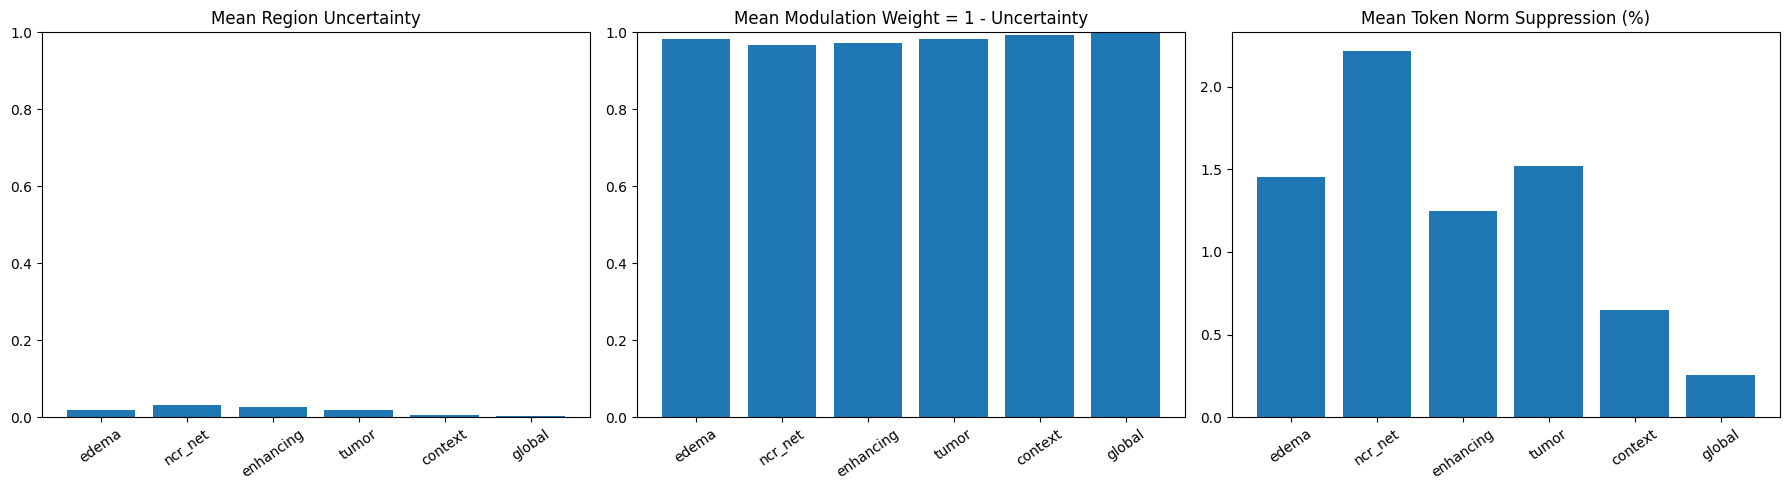

UGTM stats visualization saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/visualizations/sample_ugtm_token_norms.png


In [ ]:
def visualize_ugtm_suppression(validation_report: dict):
    regions = TOKEN_REGION_NAMES

    mean_uncertainty = [
        validation_report["mean_uncertainty_per_region"].get(region, 0.0)
        for region in regions
    ]

    mean_weight = [
        validation_report["mean_modulation_weight_per_region"].get(region, 0.0)
        for region in regions
    ]

    suppression = [
        validation_report["mean_suppression_percent_per_region"].get(region, 0.0)
        for region in regions
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].bar(regions, mean_uncertainty)
    axes[0].set_title("Mean Region Uncertainty")
    axes[0].set_ylim(0, 1)
    axes[0].tick_params(axis="x", rotation=35)

    axes[1].bar(regions, mean_weight)
    axes[1].set_title("Mean Modulation Weight = 1 - Uncertainty")
    axes[1].set_ylim(0, 1)
    axes[1].tick_params(axis="x", rotation=35)

    axes[2].bar(regions, suppression)
    axes[2].set_title("Mean Token Norm Suppression (%)")
    axes[2].tick_params(axis="x", rotation=35)

    plt.tight_layout()
    plt.savefig(SAMPLE_UGTM_STATS_VIS_PATH, dpi=150, bbox_inches="tight")
    plt.show()

    print("UGTM stats visualization saved:", SAMPLE_UGTM_STATS_VIS_PATH)


visualize_ugtm_suppression(ugtm_validation_report)


# Final Phase 2C Report

In [ ]:
ugtm_files = sorted(UGTM_SAVE_DIR.glob("*.pt"))
global_ugtm_manifest_df = rebuild_global_ugtm_manifest()

final_report = {
    "finished_at": now_string(),
    "phase": "Phase 2C - Uncertainty-Guided Token Modulation",
    "status": "complete_or_resume_ready",
    "formula": UGTM_FORMULA,
    "ugtm_files": len(ugtm_files),
    "manifest_rows": int(len(global_ugtm_manifest_df)) if len(global_ugtm_manifest_df) else 0,
    "region_names": TOKEN_REGION_NAMES,
    "token_dim": TOKEN_DIM,
    "ugtm_save_dir": str(UGTM_SAVE_DIR),
    "global_ugtm_manifest_path": str(GLOBAL_UGTM_MANIFEST_PATH),
    "validation_summary_path": str(UGTM_VALIDATION_SUMMARY_PATH),
    "sample_visualization_path": str(SAMPLE_UGTM_STATS_VIS_PATH),
    "save_original_token_copy": SAVE_ORIGINAL_TOKEN_COPY,
    "save_modulated_token_dtype": SAVE_MODULATED_TOKEN_DTYPE,
    "next_step": "QGCA/QGAG: use modulated_tokens for question-guided cross-attention and answer prediction.",
    "ablation_ready_outputs": {
        "raw_tokens": "original_tokens",
        "proposed_tokens": "modulated_tokens",
        "uncertainty_scores": "region_uncertainty",
        "weights": "modulation_weights",
    },
}

atomic_write_json(FINAL_PHASE2C_REPORT_PATH, final_report)

print("=" * 80)
print("BrainTumorVQA Phase 2C Report")
print("=" * 80)
print("Status: complete or safely resumable")
print("UGTM patient files:", len(ugtm_files))
print("Manifest rows:", len(global_ugtm_manifest_df))
print("Formula:", UGTM_FORMULA)
print("Region names:", TOKEN_REGION_NAMES)
print("Token dimension:", TOKEN_DIM)
print("UGTM directory:", UGTM_SAVE_DIR)
print("Global UGTM manifest:", GLOBAL_UGTM_MANIFEST_PATH)
print("Validation summary:", UGTM_VALIDATION_SUMMARY_PATH)
print("Final report:", FINAL_PHASE2C_REPORT_PATH)
print("=" * 80)

if len(global_ugtm_manifest_df) < 79864:
    print("\nPhase 2C is not full-dataset complete yet.")
    print("This is okay if Phase 2B is still running or incomplete.")
    print("Rerun Phase 2C later; existing completed patient files will be skipped.")
else:
    print("\nPhase 2C appears complete for all expected valid slices.")
    print("You can now use modulated_tokens for QGCA/QGAG.")


Global UGTM manifest saved: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/logs/global_ugtm_manifest.csv
Rows: 79864
BrainTumorVQA Phase 2C Report
Status: complete or safely resumable
UGTM patient files: 1251
Manifest rows: 79864
Formula: token * (1 - uncertainty)
Region names: ['edema', 'ncr_net', 'enhancing', 'tumor', 'context', 'global']
Token dimension: 512
UGTM directory: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/modulated_tokens_by_patient
Global UGTM manifest: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/logs/global_ugtm_manifest.csv
Validation summary: /content/drive/MyDrive/AMIR Lab/Research Assistant Intern/research_01_brain_tumor_VQA_medical_imaging/phase_2c_ugtm_modulated_tokens/logs/ugtm_validation_summary.json
F

# ============================================================
